<a href="https://colab.research.google.com/github/mbenedicto99/Python4DataScience/blob/master/BENE_Enunciado_do_Trabalho2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 2 — Análise de Perfis de Clientes no Setor Aéreo com Métodos de Aprendizado Não Supervisionado

Nome 1: Marcos de Benedicto

A base de dados **Airline Passenger Satisfaction** contém registros de passageiros de uma companhia aérea, incluindo informações demográficas (idade, gênero, tipo de cliente, classe de viagem), dados do voo (distância percorrida, atrasos de partida e chegada) e avaliações sobre diferentes aspectos do serviço (como conforto do assento, limpeza, Wi-Fi a bordo, manuseio da bagagem e atendimento). Além disso, há uma variável indicando o nível de satisfação geral do passageiro (satisfeito ou não).

O objetivo deste trabalho é aplicar técnicas de aprendizado não supervisionado para identificar diferentes perfis de clientes a partir da base **Airline Passenger Satisfaction**. A partir da análise exploratória, pré-processamento e agrupamento dos dados, você deverá caracterizar os perfis de clientes encontrados e propor recomendações de marketing direcionadas a cada grupo.

## Parte 1. Análise Exploratória de Dados

Nesta primeira etapa do trabalho, o objetivo é realizar uma análise exploratória dos dados para compreender melhor a base Airline Passenger Satisfaction. A partir da investigação das variáveis disponíveis, da verificação de valores ausentes, da análise de distribuições e da comparação entre diferentes grupos de passageiros, você deverá identificar padrões iniciais e possíveis fatores relacionados ao nível de satisfação do cliente.

Para implementar esta análise, você deverá responder as perguntas abaixo. Além da resposta por extenso, você deve apresentar o código que usou para encontrar a resposta. Sempre que possível, adicione comentários nas linhas de código para ajudar o professor na correção

### 1.1. Quantas linhas e colunas existem na base? Quais são os tipos de variáveis (numéricas, categóricas)?

Resposta:

In [4]:
#Insira seu código aqui
# === EDA - Questão 1.1: Linhas/colunas e tipos de variáveis ===
# Compatível com pandas >= 2.x e sem DeprecationWarning

import pandas as pd
from pathlib import Path

# 1) Arquivos candidatos (prioriza 'airlinedatabase.csv', senão usa 'dados.csv')
candidatos = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]

arquivo = None
for p in candidatos:
    if p.exists():
        arquivo = p
        break

if arquivo is None:
    raise FileNotFoundError("Nenhum arquivo encontrado em: data/airlinedatabase.csv ou data/dados.csv")

# 2) Carregar CSV (low_memory=False evita dtypes quebrados em colunas grandes)
df = pd.read_csv(arquivo, low_memory=False)

# 3) Quantidade de linhas e colunas
n_linhas, n_colunas = df.shape

# 4) Tipos por papel analítico (usando select_dtypes para evitar warnings)
cols_numericas   = df.select_dtypes(include="number").columns.tolist()
cols_categoricas = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
cols_datetime    = df.select_dtypes(include=["datetime"]).columns.tolist()

# (Opcional) tentar converter colunas com “cara” de data
# Heurística: nomes contendo 'date', 'time', 'data', 'dt'
possiveis_datas = [c for c in df.columns if any(k in c.lower() for k in ["date", "time", "data", "dt"])]
for c in possiveis_datas:
    # Só tenta se ainda não for datetime
    if c not in cols_datetime:
        try:
            conv = pd.to_datetime(df[c], errors="raise", infer_datetime_format=True, utc=False)
            df[c] = conv
        except Exception:
            pass  # deixa como está se não for conversível

# Recalcular após possíveis conversões
cols_numericas   = df.select_dtypes(include="number").columns.tolist()
cols_categoricas = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
cols_datetime    = df.select_dtypes(include=["datetime"]).columns.tolist()

# 5) Numéricas com baixa cardinalidade (podem ser tratadas como categóricas/ordinais)
possiveis_cat_numericas = []
for c in cols_numericas:
    nunq = df[c].nunique(dropna=True)
    if nunq <= max(20, int(0.01 * n_linhas)):  # <=20 ou <=1% das linhas
        possiveis_cat_numericas.append((c, nunq))

# 6) Impressão dos resultados
print("==== RESUMO EDA — Questão 1.1 ====")
print(f"Arquivo analisado: {arquivo}")
print(f"- Linhas:  {n_linhas}")
print(f"- Colunas: {n_colunas}\n")

print("Tipos de variáveis (pandas dtypes):")
for col, tp in df.dtypes.items():
    print(f"  • {col}: {tp}")

print("\nAgrupamento por papel analítico:")
print(f"  • Numéricas ({len(cols_numericas)}): {cols_numericas}")
print(f"  • Categóricas ({len(cols_categoricas)}): {cols_categoricas}")
if cols_datetime:
    print(f"  • Datas/tempos ({len(cols_datetime)}): {cols_datetime}")

if possiveis_cat_numericas:
    print("\nNuméricas com baixa cardinalidade (podem ser categóricas/ordinais):")
    for c, nunq in possiveis_cat_numericas:
        print(f"   - {c}: {nunq} valores únicos")

/tmp/ipython-input-4074070109.py:38: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  conv = pd.to_datetime(df[c], errors="raise", infer_datetime_format=True, utc=False)


==== RESUMO EDA — Questão 1.1 ====
Arquivo analisado: data/airlinedatabase.csv
- Linhas:  103904
- Colunas: 25

Tipos de variáveis (pandas dtypes):
  • Unnamed: 0: int64
  • id: int64
  • Gender: object
  • Customer Type: object
  • Age: int64
  • Type of Travel: object
  • Class: object
  • Flight Distance: int64
  • Inflight wifi service: int64
  • Departure/Arrival time convenient: datetime64[ns]
  • Ease of Online booking: int64
  • Gate location: int64
  • Food and drink: int64
  • Online boarding: int64
  • Seat comfort: int64
  • Inflight entertainment: int64
  • On-board service: int64
  • Leg room service: int64
  • Baggage handling: int64
  • Checkin service: int64
  • Inflight service: int64
  • Cleanliness: int64
  • Departure Delay in Minutes: int64
  • Arrival Delay in Minutes: float64
  • satisfaction: object

Agrupamento por papel analítico:
  • Numéricas (19): ['Unnamed: 0', 'id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Ease of Online booking', 'Gate locati

### 1.2. Existem variáveis com valores nulos? Como esses valores estão distribuídos?

Resposta:

In [5]:
#Insira seu código aqui
# === EDA - Questão 1.2: Existem valores nulos? Como estão distribuídos? ===
import pandas as pd
from pathlib import Path

# 1) Localizar o arquivo
candidatos = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
arquivo = next((p for p in candidatos if p.exists()), None)
if arquivo is None:
    raise FileNotFoundError("Nenhum arquivo encontrado em: data/airlinedatabase.csv ou data/dados.csv")

# 2) Carregar
df = pd.read_csv(arquivo, low_memory=False)

# 3) Panorama geral de nulos
total_celulas = df.shape[0] * df.shape[1]
nulos_por_col = df.isna().sum().sort_values(ascending=False)
pct_por_col   = (nulos_por_col / len(df) * 100).round(2)
tem_nulos = int(nulos_por_col.sum())

print("==== RESUMO EDA — Questão 1.2 ====")
print(f"Arquivo analisado: {arquivo}")
print(f"- Linhas: {len(df)} | Colunas: {df.shape[1]}")
print(f"- Células totais: {total_celulas:,}")
print(f"- Células nulas:  {tem_nulos:,} ({(tem_nulos/total_celulas*100):.2f}%)\n")

# 4) Distribuição por coluna (exibir apenas colunas com nulos)
mask_tem_nulo = nulos_por_col > 0
if mask_tem_nulo.any():
    resumo_nulos = pd.DataFrame({
        "coluna": nulos_por_col.index,
        "n_nulos": nulos_por_col.values,
        "%_linhas_com_nulo": pct_por_col.values
    })
    resumo_nulos = resumo_nulos[resumo_nulos["n_nulos"] > 0]
    print("Colunas com valores nulos (ordenado por n_nulos):")
    print(resumo_nulos.to_string(index=False))
else:
    print("Não há valores nulos em nenhuma coluna.")

# 5) Linhas afetadas (quantas linhas têm >=1 nulo)
linhas_com_1oumais = df.isna().any(axis=1).sum()
print(f"\nLinhas com ≥1 nulo: {linhas_com_1oumais} ({linhas_com_1oumais/len(df)*100:.2f}% das linhas)")

# 6) (Opcional) Colunas com maior proporção de nulos (top 10)
if mask_tem_nulo.any():
    top10 = resumo_nulos.sort_values("%_linhas_com_nulo", ascending=False).head(10)
    print("\nTop 10 colunas por % de nulos:")
    print(top10.to_string(index=False))

# 7) (Opcional) Distribuição de nulos por classe da satisfação (se existir coluna-âncora)
possiveis_alvos = [c for c in ["satisfaction","Satisfaction","target","label"] if c in df.columns]
if possiveis_alvos:
    alvo = possiveis_alvos[0]
    print(f"\nDistribuição de nulos por classe da coluna-alvo: '{alvo}'")
    # Para cada coluna com nulo, calcular % de nulo dentro de cada classe do alvo
    for col in nulos_por_col.index[nulos_por_col > 0]:
        taxa_por_classe = (
            df.groupby(alvo)[col]
              .apply(lambda s: s.isna().mean()*100)
              .round(2)
              .rename("%_nulo")
        )
        print(f"- {col}:")
        print(taxa_por_classe.to_string())
else:
    print("\n!!!Não encontrei coluna de satisfação entre ['satisfaction','Satisfaction','target','label']; "
          "pulei a análise de nulos por classe.")

==== RESUMO EDA — Questão 1.2 ====
Arquivo analisado: data/airlinedatabase.csv
- Linhas: 103904 | Colunas: 25
- Células totais: 2,597,600
- Células nulas:  310 (0.01%)

Colunas com valores nulos (ordenado por n_nulos):
                  coluna  n_nulos  %_linhas_com_nulo
Arrival Delay in Minutes      310                0.3

Linhas com ≥1 nulo: 310 (0.30% das linhas)

Top 10 colunas por % de nulos:
                  coluna  n_nulos  %_linhas_com_nulo
Arrival Delay in Minutes      310                0.3

Distribuição de nulos por classe da coluna-alvo: 'satisfaction'
- Arrival Delay in Minutes:
satisfaction
neutral or dissatisfied    0.31
satisfied                  0.28


### 1.3. Qual a proporção de clientes satisfeitos vs. não satisfeitos? Qual a proporção de clientes leais vs. ocasionais (Loyal Customer / Disloyal Customer)?

Resposta:

In [6]:
#Insira seu código aqui
# === EDA 1.3: Proporção Satisfeitos vs. Não; Loyal vs. Disloyal ===
import pandas as pd
from pathlib import Path

# 1) Carregar dataset (prioriza airlinedatabase.csv; senão usa dados.csv)
candidatos = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
arquivo = next((p for p in candidatos if p.exists()), None)
if arquivo is None:
    raise FileNotFoundError("Nenhum arquivo encontrado em data/airlinedatabase.csv ou data/dados.csv")

df = pd.read_csv(arquivo, low_memory=False)

# 2) Detectar possíveis colunas de satisfação e lealdade
possiveis_sat = [c for c in df.columns if c.lower().strip().replace(" ", "").replace("_", "") in
                 {"satisfaction","satisfacao","satisfacation"}] or \
                [c for c in df.columns if "satisf" in c.lower()]

possiveis_loyal = [c for c in df.columns if c.lower().strip().replace(" ", "").replace("_", "") in
                   {"customertype","loyalty","loyal","clientetype"}] or \
                  [c for c in df.columns if ("loyal" in c.lower()) or ("customer type" in c.lower()) or ("customer_type" in c.lower())]

col_sat = possiveis_sat[0] if possiveis_sat else None
col_loyal = possiveis_loyal[0] if possiveis_loyal else None

def proporcoes_satisfacao(series):
    # Normalização de rótulos comuns do dataset (Kaggle)
    s = series.astype(str).str.strip().str.lower()
    s = s.replace({
        "neutral or dissatisfied":"not satisfied",
        "dissatisfied":"not satisfied",
        "satisfied":"satisfied",
        "1":"satisfied","0":"not satisfied"
    })
    total = s.notna().sum()
    dist = (s.value_counts(dropna=True) / total * 100).round(2)
    return total, dist

def proporcoes_loyal(series):
    s = series.astype(str).str.strip().str.lower()
    s = s.replace({
        "loyal customer":"loyal",
        "disloyal customer":"disloyal"
    })
    total = s.notna().sum()
    dist = (s.value_counts(dropna=True) / total * 100).round(2)
    return total, dist

print("==== EDA 1.3 ====")
print(f"Arquivo analisado: {arquivo.name}")

if col_sat:
    n, dist = proporcoes_satisfacao(df[col_sat])
    print(f"\nColuna de satisfação: {col_sat} (n={n})")
    for k, v in dist.items():
        print(f"  - {k}: {v}%")
else:
    print("\n!!!Não foi encontrada coluna de satisfação por heurística.")

if col_loyal:
    n, dist = proporcoes_loyal(df[col_loyal])
    print(f"\nColuna de lealdade: {col_loyal} (n={n})")
    for k, v in dist.items():
        print(f"  - {k}: {v}%")
else:
    print("\n!!!Não foi encontrada coluna de lealdade por heurística.")

==== EDA 1.3 ====
Arquivo analisado: airlinedatabase.csv

Coluna de satisfação: satisfaction (n=103904)
  - not satisfied: 56.67%
  - satisfied: 43.33%

Coluna de lealdade: Customer Type (n=103904)
  - loyal: 81.73%
  - disloyal: 18.27%


### 1.4. Qual a proporção da variável Gender? Como a idade dos passageiros está distribuída? Qual a proporção por Class (Business, Eco, Eco Plus)? Qual a proporção por Type of Travel (Business / Personal)?

Resposta:

In [7]:
#Insira seu código aqui
# === EDA 1.4: Gender, Age, Class e Type of Travel ===
import pandas as pd
from pathlib import Path
import numpy as np

# 1) Carregar dataset (prioriza airlinedatabase.csv; senão dados.csv)
candidatos = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
arquivo = next((p for p in candidatos if p.exists()), None)
if arquivo is None:
    raise FileNotFoundError("Nenhum arquivo encontrado em data/")

df = pd.read_csv(arquivo, low_memory=False)

# 2) Heurística de nomes
def achar(colunas, chaves):
    for c in colunas:
        key = c.lower().strip().replace("_"," ").replace("-"," ")
        if any(k in key for k in chaves):
            return c
    return None

col_gender = achar(df.columns, ["gender"])
col_age    = achar(df.columns, ["age","idade"])
col_class  = achar(df.columns, ["class"])
col_travel = achar(df.columns, ["type of travel","travel type","type","viagem"])

print(f"==== EDA 1.4 (Arquivo: {arquivo.name}) ====")

# 3) Proporção Gender
if col_gender:
    g = (df[col_gender].astype(str).str.strip().str.title()
         .replace({"M":"Male","F":"Female"}))
    prop_gender = (g.value_counts(dropna=True, normalize=True)*100).round(2)
    print(f"\nProporção por {col_gender}:")
    for k, v in prop_gender.items():
        print(f"  - {k}: {v}%")
else:
    print("\n!!!Coluna de Gender não encontrada.")

# 4) Distribuição de Age (estatísticas + faixas)
if col_age:
    age = pd.to_numeric(df[col_age], errors="coerce")
    descr = age.describe(percentiles=[.1,.25,.5,.75,.9,.95]).round(2)
    print("\nIdade — estatísticas:")
    print(descr.to_string())

    # Faixas de idade (para resumir a distribuição)
    bins = [0,17,25,35,45,55,65,75,120]
    labels = ["0-17","18-25","26-35","36-45","46-55","56-65","66-75","76+"]
    age_bins = pd.cut(age, bins=bins, labels=labels, right=True, include_lowest=True)
    dist_bins = (age_bins.value_counts(normalize=True, dropna=True)*100).round(2).reindex(labels)
    print("\nDistribuição por faixas de idade (%):")
    for faixa, v in dist_bins.items():
        print(f"  - {faixa}: {v if pd.notna(v) else 0.0}%")
else:
    print("\n!!!Coluna de Age não encontrada.")

# 5) Proporção por Class
if col_class:
    c = df[col_class].astype(str).str.strip().str.title()
    c = c.replace({"Economy":"Eco"})  # normalização comum
    prop_class = (c.value_counts(dropna=True, normalize=True)*100).round(2)
    print(f"\nProporção por {col_class}:")
    for k, v in prop_class.items():
        print(f"  - {k}: {v}%")
else:
    print("\n!!!Coluna de Class não encontrada.")

# 6) Proporção por Type of Travel (se existir Business/Personal)
if col_travel:
    t = df[col_travel].astype(str).str.strip().str.title()
    t = t.replace({"Business Travel":"Business","Personal Travel":"Personal"})
    prop_travel = (t.value_counts(dropna=True, normalize=True)*100).round(2)
    print(f"\nProporção por {col_travel}:")
    for k, v in prop_travel.items():
        print(f"  - {k}: {v}%")
else:
    print("\n(Nota) Coluna de 'Type of Travel' não encontrada nesta versão da base.")

==== EDA 1.4 (Arquivo: airlinedatabase.csv) ====

Proporção por Gender:
  - Female: 50.75%
  - Male: 49.25%

Idade — estatísticas:
count    103904.00
mean         39.38
std          15.11
min           7.00
10%          20.00
25%          27.00
50%          40.00
75%          51.00
90%          59.00
95%          64.00
max          85.00

Distribuição por faixas de idade (%):
  - 0-17: 7.63%
  - 18-25: 14.13%
  - 26-35: 18.14%
  - 36-45: 23.63%
  - 46-55: 20.16%
  - 56-65: 12.45%
  - 66-75: 3.56%
  - 76+: 0.29%

Proporção por Class:
  - Business: 47.8%
  - Eco: 44.99%
  - Eco Plus: 7.21%

Proporção por Customer Type:
  - Loyal Customer: 81.73%
  - Disloyal Customer: 18.27%


### 1.5. Qual a média e mediana da Flight Distance? Qual a distribuição de atrasos na partida e chegada? Há presença de outliers nessas variáveis?

Resposta:

==== EDA 1.5 (Arquivo: airlinedatabase.csv) ====

Flight Distance:
  média=1189.45 | mediana=843.00
  Q1=414.00 | Q3=1743.00 | IQR=1329.00
  Limites (1.5*IQR): [-1579.50, 3736.50]
  Outliers: 2291 (2.20%)

Departure Delay (min):
  média=14.82 | mediana=0.00
  Q1=0.00 | Q3=12.00 | IQR=12.00
  Limites (1.5*IQR): [-18.00, 30.00]
  Outliers: 14529 (13.98%)

Arrival Delay (min):
  média=15.18 | mediana=0.00
  Q1=0.00 | Q3=13.00 | IQR=13.00
  Limites (1.5*IQR): [-19.50, 32.50]
  Outliers: 13954 (13.47%)


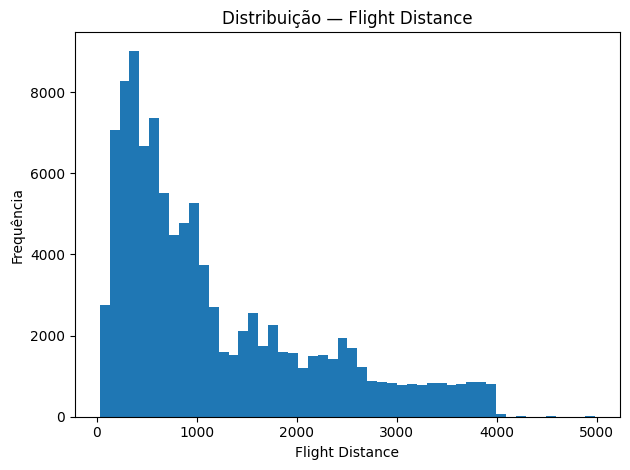

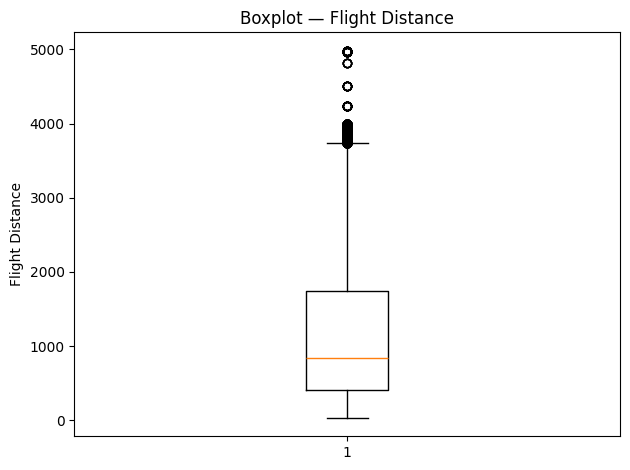

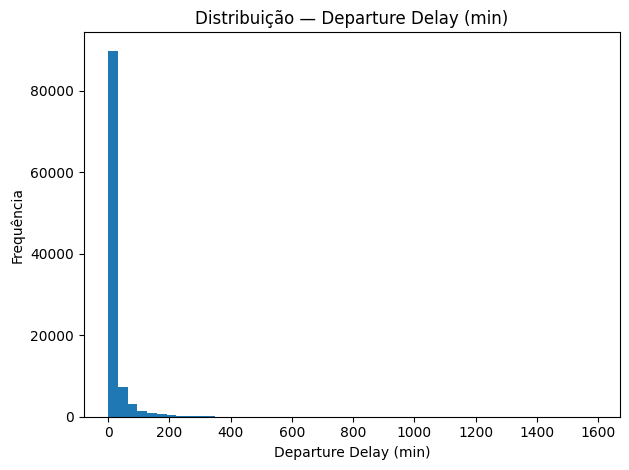

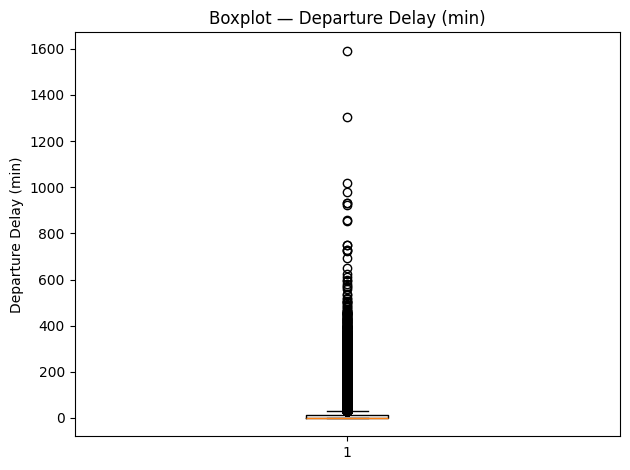

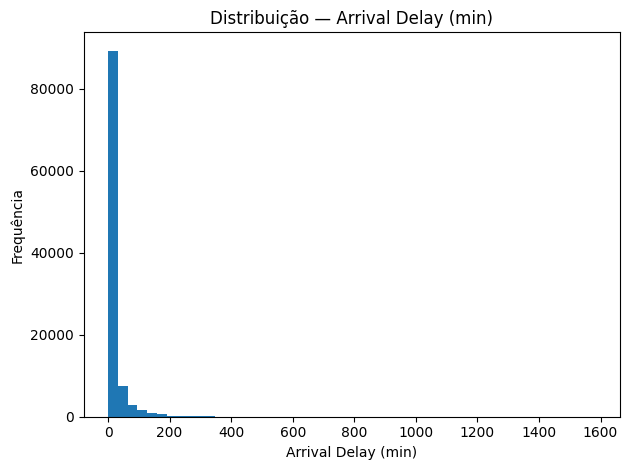

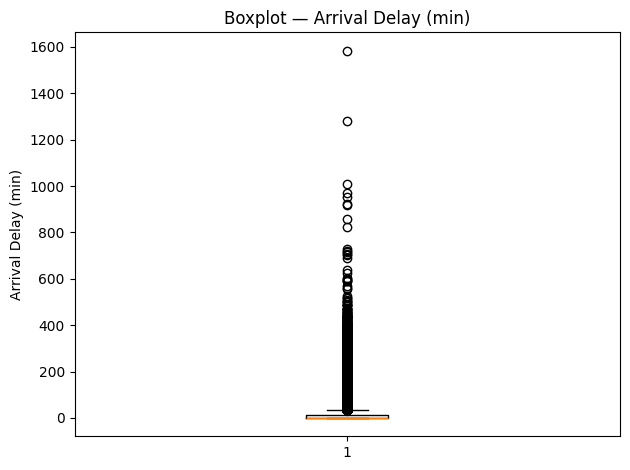

In [8]:
#Insira seu código aqui
# === EDA 1.5: Flight Distance, Departure/Arrival Delay e Outliers (1.5*IQR) ===
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# 1) Carregar base (prioriza airlinedatabase.csv; senão dados.csv)
candidatos = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
arquivo = next((p for p in candidatos if p.exists()), None)
if arquivo is None:
    raise FileNotFoundError("Nenhum arquivo encontrado em data/")
df = pd.read_csv(arquivo, low_memory=False)

# 2) Encontrar colunas
def pick(cols, keys):
    for c in cols:
        k = c.lower().strip().replace("_"," ").replace("-"," ")
        if any(key in k for key in keys):
            return c
    return None

col_dist   = pick(df.columns, ["flight distance","distance"])
col_depdel = pick(df.columns, ["departure delay","dep delay","delay departure"])
col_arrdel = pick(df.columns, ["arrival delay","arr delay","delay arrival"])

to_num = lambda s: pd.to_numeric(s, errors="coerce")
fd = to_num(df[col_dist])   if col_dist   else None
dd = to_num(df[col_depdel]) if col_depdel else None
ad = to_num(df[col_arrdel]) if col_arrdel else None

# 3) Função de estatística + outliers por IQR
def basic_stats(series):
    s = series.dropna()
    mean = s.mean(); median = s.median()
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = ((s < low) | (s > high)).sum()
    perc_out = outliers/len(s)*100
    return mean, median, q1, q3, iqr, low, high, outliers, perc_out

def show_stats(name, s):
    mean, median, q1, q3, iqr, low, high, outliers, perc_out = basic_stats(s)
    print(f"\n{name}:")
    print(f"  média={mean:.2f} | mediana={median:.2f}")
    print(f"  Q1={q1:.2f} | Q3={q3:.2f} | IQR={iqr:.2f}")
    print(f"  Limites (1.5*IQR): [{low:.2f}, {high:.2f}]")
    print(f"  Outliers: {outliers} ({perc_out:.2f}%)")

print(f"==== EDA 1.5 (Arquivo: {arquivo.name}) ====")
if fd is not None: show_stats("Flight Distance", fd)
if dd is not None: show_stats("Departure Delay (min)", dd)
if ad is not None: show_stats("Arrival Delay (min)", ad)

# 4) Gráficos (um por figura; sem definir cores)
def plot_hist(s, title, xlabel):
    s = s.dropna()
    plt.figure()
    s.plot(kind="hist", bins=50)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel("Frequência")
    plt.tight_layout(); plt.show()

def plot_box(s, title, ylabel):
    s = s.dropna()
    plt.figure()
    plt.boxplot(s.values, vert=True, showfliers=True)
    plt.title(title); plt.ylabel(ylabel)
    plt.tight_layout(); plt.show()

if fd is not None:
    plot_hist(fd, "Distribuição — Flight Distance", "Flight Distance")
    plot_box(fd, "Boxplot — Flight Distance", "Flight Distance")

if dd is not None:
    plot_hist(dd, "Distribuição — Departure Delay (min)", "Departure Delay (min)")
    plot_box(dd, "Boxplot — Departure Delay (min)", "Departure Delay (min)")

if ad is not None:
    plot_hist(ad, "Distribuição — Arrival Delay (min)", "Arrival Delay (min)")
    plot_box(ad, "Boxplot — Arrival Delay (min)", "Arrival Delay (min)")

### 1.6. Quais serviços apresentam maiores notas médias? Quais serviços apresentam maiores variações nas avaliações (clientes mais divergentes)?

Resposta:

In [9]:
#Insira seu código aqui
# === EDA 1.6: Serviços com maiores médias e maiores variações ===
import pandas as pd
import numpy as np
from pathlib import Path

# 1) Carregar dataset
candidatos = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
arquivo = next((p for p in candidatos if p.exists()), None)
if arquivo is None:
    raise FileNotFoundError("Nenhum arquivo encontrado em data/")
df = pd.read_csv(arquivo, low_memory=False)

# 2) Detectar colunas de avaliação em escala (0–5 ou 1–5)
num_cols = df.select_dtypes(include="number").columns.tolist()

def is_rating_series(s):
    s = pd.to_numeric(s, errors="coerce")
    if s.notna().sum() == 0:
        return False
    vmin, vmax = s.min(), s.max()
    # ratings típicos; 0 pode significar “sem serviço”
    return (0 <= vmin <= 1) and (vmax <= 5) and (s.dropna().astype(float).apply(float.is_integer).mean() > 0.95)

rating_cols = [c for c in num_cols if is_rating_series(df[c])]
ratings = df[rating_cols].apply(pd.to_numeric, errors="coerce")

# 3) Métricas com duas suposições:
#    A) zeros contam como nota válida; B) zeros = “sem serviço” (excluir)
ratings0 = ratings
ratings_excl0 = ratings.mask(ratings == 0)

tabela = pd.DataFrame({
    "n": ratings0.count(),
    "mean_incl_zero": ratings0.mean(),
    "std_incl_zero":  ratings0.std(ddof=1),
    "n_excl_zero":    ratings_excl0.count(),
    "mean_excl_zero": ratings_excl0.mean(),
    "std_excl_zero":  ratings_excl0.std(ddof=1),
}).sort_values("mean_excl_zero", ascending=False)

# 4) Rankings solicitados (usando cenário B — zeros excluídos)
top_media    = tabela.sort_values("mean_excl_zero", ascending=False).head(10)
top_variacao = tabela.sort_values("std_excl_zero",  ascending=False).head(10)

print(f"Arquivo analisado: {arquivo.name}\n")
print("Top 5 por maior média (0 como NA):")
for idx, row in top_media.head(5).iterrows():
    print(f"- {idx}: média={row['mean_excl_zero']:.2f} (n={int(row['n_excl_zero'])})")

print("\nTop 5 por maior variação (std; 0 como NA):")
for idx, row in top_variacao.head(5).iterrows():
    print(f"- {idx}: std={row['std_excl_zero']:.2f} (n={int(row['n_excl_zero'])})")

Arquivo analisado: airlinedatabase.csv

Top 5 por maior média (0 como NA):
- Inflight service: média=3.64 (n=103901)
- Baggage handling: média=3.63 (n=103904)
- Seat comfort: média=3.44 (n=103903)
- On-board service: média=3.38 (n=103901)
- Leg room service: média=3.37 (n=103432)

Top 5 por maior variação (std; 0 como NA):
- Departure/Arrival time convenient: std=1.39 (n=98604)
- Inflight entertainment: std=1.33 (n=103890)
- Food and drink: std=1.33 (n=103797)
- Seat comfort: std=1.32 (n=103903)
- Cleanliness: std=1.31 (n=103892)


### 1.7. Construa a matriz de correlação entre as variáveis numéricas. Quais variáveis parecem estar mais relacionadas entre si?

Resposta:

==== EDA 1.7 (Arquivo: airlinedatabase.csv) ====
Top 10 pares (Pearson; 0 dos ratings como NA):
- Departure Delay in Minutes × Arrival Delay in Minutes: corr=0.965
- Inflight entertainment × Cleanliness: corr=0.692
- Inflight wifi service × Ease of Online booking: corr=0.687
- Seat comfort × Cleanliness: corr=0.679
- Food and drink × Cleanliness: corr=0.659
- Baggage handling × Inflight service: corr=0.629
- Food and drink × Inflight entertainment: corr=0.624
- Seat comfort × Inflight entertainment: corr=0.611
- Food and drink × Seat comfort: corr=0.576
- On-board service × Inflight service: corr=0.551


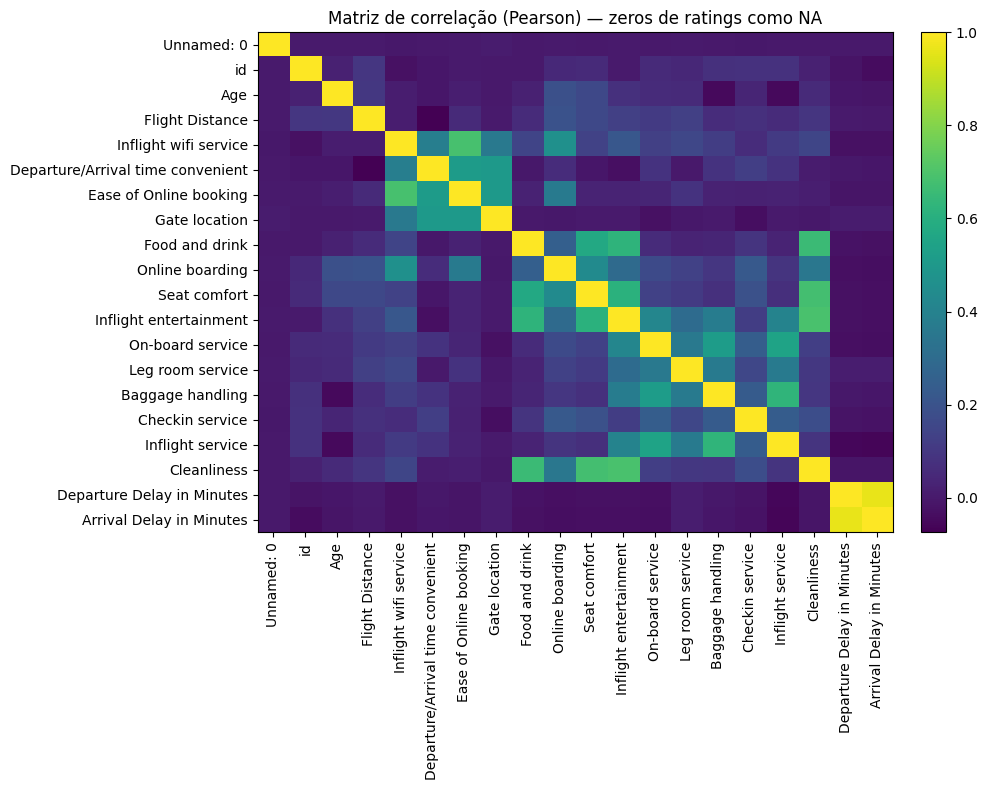

In [10]:
#Insira seu código aqui
# === EDA 1.7: Correlação entre variáveis numéricas ===
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# 1) Carregar base
candidatos = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
arquivo = next((p for p in candidatos if p.exists()), None)
if arquivo is None:
    raise FileNotFoundError("Nenhum arquivo encontrado em data/")
df = pd.read_csv(arquivo, low_memory=False)

# 2) Selecionar numéricas
num_df = df.select_dtypes(include="number").copy()

# 3) Opcional: tratar 0 como NA nas colunas de rating (0–5)
def is_rating_series(s):
    s = pd.to_numeric(s, errors="coerce")
    if s.notna().sum() == 0: return False
    vmin, vmax = s.min(), s.max()
    return (0 <= vmin <= 1) and (vmax <= 5) and (s.dropna().astype(float).apply(float.is_integer).mean() > 0.95)

rating_cols = [c for c in num_df.columns if is_rating_series(num_df[c])]
num_df_alt = num_df.copy()
num_df_alt[rating_cols] = num_df_alt[rating_cols].mask(num_df_alt[rating_cols] == 0)

# 4) Correlações (Pearson)
corr = num_df_alt.corr(numeric_only=True, method="pearson")

# 5) Pegar pares mais fortes (ignora diagonal e duplicidade)
import numpy as np
c = corr.copy()
np.fill_diagonal(c.values, np.nan)
pairs = (c.abs().stack().reset_index()
         .rename(columns={"level_0":"var1","level_1":"var2",0:"abs_corr"}))
pairs["key"] = pairs.apply(lambda r: tuple(sorted([r["var1"], r["var2"]])), axis=1)
pairs = pairs.drop_duplicates(subset="key").drop(columns="key")
pairs["corr"] = pairs.apply(lambda r: corr.loc[r["var1"], r["var2"]], axis=1)
top = pairs.sort_values("abs_corr", ascending=False).head(15)

print(f"==== EDA 1.7 (Arquivo: {arquivo.name}) ====")
print("Top 10 pares (Pearson; 0 dos ratings como NA):")
for _, r in top.head(10).iterrows():
    print(f"- {r['var1']} × {r['var2']}: corr={r['corr']:.3f}")

# 6) Heatmap (um gráfico; sem definir cores)
plt.figure(figsize=(10,8))
im = plt.imshow(corr.values, aspect='auto')
plt.title("Matriz de correlação (Pearson) — zeros de ratings como NA")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### 1.8. Além das análises solicitadas acima, escolha pelo menos um aspecto adicional da base que você considera relevante investigar e apresente-a (pode ser uma tabela, estatística ou visualização, com gráficos ou histogramas)

Resposta:

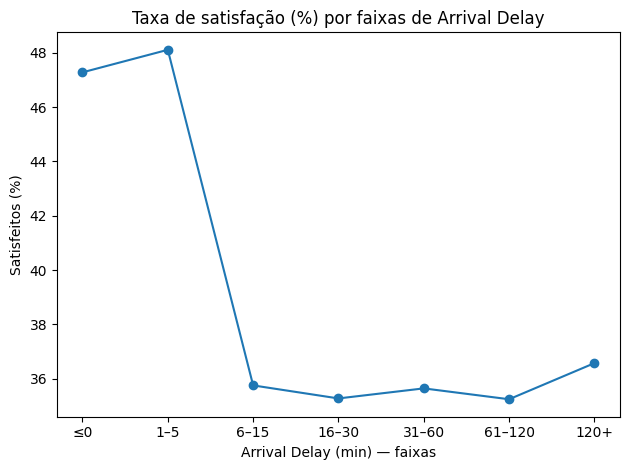


Taxa de satisfação (%) por Class × Customer Type:
Customer Type  Loyal Customer  disloyal Customer
Class                                           
Business                74.62              39.55
Eco                     20.02              14.00
Eco Plus                26.38               7.83


In [12]:
#Insira seu código aqui
# === EDA 1.8 (corrigido para o FutureWarning de observed) ===
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Carregar dataset
candidatos = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
arquivo = next((p for p in candidatos if p.exists()), None)
if arquivo is None:
    raise FileNotFoundError("Nenhum arquivo encontrado em data/")
df = pd.read_csv(arquivo, low_memory=False)

# Satisfação -> binária
sat_col = next((c for c in df.columns if "satisf" in c.lower()), None)
sat = df[sat_col].astype(str).str.strip().str.lower().replace({
    "neutral or dissatisfied":"not satisfied",
    "dissatisfied":"not satisfied",
    "satisfied":"satisfied"
})
df["_satisfied"] = (sat == "satisfied").astype(int)

# Arrival Delay (min) + bins categóricos ordenados
arr_col = next((c for c in df.columns if "arrival delay" in c.lower()), None)
arr = pd.to_numeric(df[arr_col], errors="coerce")

bins = [-np.inf, 0, 5, 15, 30, 60, 120, np.inf]
labels = ["≤0", "1–5", "6–15", "16–30", "31–60", "61–120", "120+"]

df["_arr_delay_bin"] = pd.cut(arr, bins=bins, labels=labels, right=True, include_lowest=True, ordered=True)

# >>> AQUI a correção: explicitar observed=False para manter o comportamento atual
tab_delay = (
    df.groupby("_arr_delay_bin", observed=False)["_satisfied"]
      .agg(taxa_satisfacao=lambda s: s.mean()*100, n="count")
      .reset_index()
)
tab_delay["taxa_satisfacao"] = tab_delay["taxa_satisfacao"].round(2)

# Garantir a ordem dos rótulos (mesmo se alguma faixa tiver n=0)
tab_delay = tab_delay.set_index("_arr_delay_bin").reindex(labels).reset_index()

# Gráfico
plt.figure()
plt.plot(tab_delay["_arr_delay_bin"].astype(str), tab_delay["taxa_satisfacao"], marker="o")
plt.title("Taxa de satisfação (%) por faixas de Arrival Delay")
plt.xlabel("Arrival Delay (min) — faixas")
plt.ylabel("Satisfeitos (%)")
plt.tight_layout()
plt.show()

# (Opcional) Tabela Class × Customer Type — também especificando observed no pivot_table via groupby interno
class_col = next((c for c in df.columns if c.lower().strip() == "class"), None)
ctype_col = next((c for c in df.columns if "customer type" in c.lower()), None)
if class_col and ctype_col:
    # pivot_table usa groupby por baixo; usamos uma agregação manual para controlar observed
    tmp = (
        df.groupby([class_col, ctype_col], observed=False)["_satisfied"]
          .mean()
          .mul(100)
          .round(2)
          .reset_index()
    )
    piv = tmp.pivot(index=class_col, columns=ctype_col, values="_satisfied")
    print("\nTaxa de satisfação (%) por Class × Customer Type:")
    print(piv.to_string())

## Parte 2. Pré-processamento

Nesta segunda etapa do trabalho, o objetivo é realizar o pré-processamento da base de dados, garantindo que ela esteja adequada para a aplicação dos métodos de aprendizado não supervisionado. Para isso, será necessário selecionar variáveis relevantes, tratar valores ausentes, transformar variáveis categóricas em numéricas e padronizar os dados. Ao final, você deverá obter uma matriz final consistente, pronta para ser utilizada nos algoritmos a serem implementados na Parte 3.

### 2.1. Existem variáveis com valores faltantes após a análise exploratória? Qual estratégia você utilizará para tratá-los (remoção, substituição por média/mediana/moda, outro método)? Explique sua decisão.

Resposta:

In [14]:
#Insira seu código aqui
# === Parte 2 — Pré-processamento para Aprendizado NÃO supervisionado ===
# Saídas: matriz X pronta (esparsa), nomes de features, pipeline joblib
# Requisitos: pandas, numpy, scikit-learn, joblib, scipy

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from scipy import sparse
from joblib import dump

# ----------------------------------------------------------------------
# 0) Configurações
# ----------------------------------------------------------------------
CANDIDATOS = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
ZERO_IS_MISSING_IN_RATINGS = True   # tratar 0 em colunas 0..5 como "sem serviço"
RANDOM_SAMPLE_FOR_CSV = 5000        # quantas linhas salvar como CSV denso para inspecionar

OUT_DIR_MODELS = Path("models"); OUT_DIR_MODELS.mkdir(parents=True, exist_ok=True)
OUT_DIR_DATA   = Path("data");   OUT_DIR_DATA.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------
# 1) Carregar dataset
# ----------------------------------------------------------------------
arquivo = next((p for p in CANDIDATOS if p.exists()), None)
if arquivo is None:
    raise FileNotFoundError("Nenhum arquivo encontrado em data/airlinedatabase.csv ou data/dados.csv")

df = pd.read_csv(arquivo, low_memory=False)
print(f"[INFO] Arquivo carregado: {arquivo} | shape={df.shape}")

# ----------------------------------------------------------------------
# 2) Remover colunas claramente inúteis/ID e separar possíveis rótulos
#    (evitar vazamento em não supervisionado)
# ----------------------------------------------------------------------
drop_ids = [c for c in df.columns if c.lower().strip() in {"id","unnamed: 0","passengerid","index"}]
label_like = [c for c in df.columns
              if any(k in c.lower() for k in ["satisf", "customer type", "target", "label"])]

cols_to_drop = drop_ids + label_like
cols_to_drop = list(dict.fromkeys(cols_to_drop))  # único e preserva ordem

if cols_to_drop:
    print(f"[INFO] Removendo colunas (ID/labels): {cols_to_drop}")
    df_proc = df.drop(columns=cols_to_drop)
else:
    df_proc = df.copy()

# ----------------------------------------------------------------------
# 3) Detectar tipos
# ----------------------------------------------------------------------
num_cols  = df_proc.select_dtypes(include="number").columns.tolist()
cat_cols  = df_proc.select_dtypes(include=["object","category","string","bool"]).columns.tolist()

# Heurística de colunas de rating 0..5 (inteiras) para tratar 0 como NA
def is_rating(s: pd.Series) -> bool:
    s = pd.to_numeric(s, errors="coerce")
    if s.notna().sum() == 0:
        return False
    vmin, vmax = s.min(), s.max()
    frac_int = (s.dropna().astype(float).apply(float.is_integer).mean() if s.notna().any() else 0.0)
    return (0 <= vmin <= 1) and (vmax <= 5) and (frac_int > 0.95)

rating_cols = [c for c in num_cols if is_rating(df_proc[c])]
print(f"[INFO] Numéricas: {len(num_cols)} | Categóricas: {len(cat_cols)} | Ratings detectadas: {rating_cols}")

# (Opcional) marcar zeros como NA nas ratings
if ZERO_IS_MISSING_IN_RATINGS and rating_cols:
    for c in rating_cols:
        s = pd.to_numeric(df_proc[c], errors="coerce")
        s = s.mask(s == 0)  # 0 -> NA
        df_proc[c] = s

# ----------------------------------------------------------------------
# 4) Pipelines de transformação
#    - Numéricas: imputar mediana + RobustScaler (mais robusto a outliers)
#    - Categóricas: imputar mais frequente + OneHot (ignorar categorias novas)
# ----------------------------------------------------------------------
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0)))
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3  # força saída esparsa quando há bastante OneHot
)

# ----------------------------------------------------------------------
# 5) Ajustar e transformar
# ----------------------------------------------------------------------
X = preprocess.fit_transform(df_proc)

# Recuperar nomes das features para OneHot
feature_names = []
# Numéricas (após scaler, nomes originais)
feature_names.extend(num_cols)
# Categóricas (nomes expandidos do OneHot)
ohe: OneHotEncoder = preprocess.named_transformers_["cat"].named_steps["onehot"]
if len(cat_cols) > 0:
    ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
else:
    ohe_names = []
feature_names.extend(ohe_names)

print(f"[INFO] Matriz final: shape={X.shape} | esparsa={sparse.issparse(X)} | features={len(feature_names)}")

# ----------------------------------------------------------------------
# 6) Persistir artefatos  (funciona para X denso ou esparso)
# ----------------------------------------------------------------------
from scipy import sparse
import numpy as np

# 6.1 Matriz
if sparse.issparse(X):
    sparse.save_npz(OUT_DIR_DATA / "processed_matrix.npz", X)
    matriz_path = OUT_DIR_DATA / "processed_matrix.npz"
else:
    np.save(OUT_DIR_DATA / "processed_matrix.npy", X)
    matriz_path = OUT_DIR_DATA / "processed_matrix.npy"

# 6.2 Nomes das features
with open(OUT_DIR_DATA / "processed_features.txt", "w", encoding="utf-8") as f:
    for nm in feature_names:
        f.write(f"{nm}\n")

# 6.3 Pipeline
from joblib import dump
dump(preprocess, OUT_DIR_MODELS / "preprocess_pipeline.joblib")

# 6.4 Amostra em CSV denso (para inspeção humana)
if RANDOM_SAMPLE_FOR_CSV and X.shape[0] > 0:
    n = min(RANDOM_SAMPLE_FOR_CSV, X.shape[0])
    rng = np.random.RandomState(42)
    idx = rng.choice(X.shape[0], size=n, replace=False)
    X_dense_sample = X[idx].toarray() if sparse.issparse(X) else X[idx]
    pd.DataFrame(X_dense_sample, columns=feature_names).to_csv(OUT_DIR_DATA / "processed_sample.csv", index=False)

print(f"[OK] Pré-processamento concluído. Matriz salva em: {matriz_path}")

[INFO] Arquivo carregado: data/airlinedatabase.csv | shape=(103904, 25)
[INFO] Removendo colunas (ID/labels): ['Unnamed: 0', 'id', 'Customer Type', 'satisfaction']
[INFO] Numéricas: 18 | Categóricas: 3 | Ratings detectadas: ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
[INFO] Matriz final: shape=(103904, 25) | esparsa=False | features=25
[OK] Pré-processamento concluído. Matriz salva em: data/processed_matrix.npy


### 2.2. Codifique as variáveis categóricas. Após a transformação, quantas variáveis a base passou a ter?

Resposta:

In [15]:
#Insira seu código aqui
# 2.2 — Codificar categóricas e contar quantas variáveis passam a existir
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1) Carregar base (prioriza airlinedatabase.csv; senão dados.csv)
candidatos = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
arquivo = next((p for p in candidatos if p.exists()), None)
df = pd.read_csv(arquivo, low_memory=False)

# 2) Remover IDs/rótulos (evitar vazamento para não supervisionado)
drop_cols = [c for c in df.columns if c.lower().strip() in {"unnamed: 0","id","passengerid"}]
drop_cols += [c for c in df.columns if any(k in c.lower() for k in ["satisf", "customer type", "target", "label"])]
df = df.drop(columns=list(dict.fromkeys(drop_cols)), errors="ignore")

# 3) Identificar tipos
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include=["object","string","category","bool"]).columns.tolist()

# 4) One-Hot das categóricas, mantendo numéricas como estão
ct = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop"
)

X = ct.fit_transform(df)

# 5) Contar variáveis (features) após transformação
#    — nomes: numéricos originais + categorias expandidas
feature_names = []
feature_names += num_cols
if cat_cols:
    ohe = ct.named_transformers_["cat"]
    feature_names += ohe.get_feature_names_out(cat_cols).tolist()

print("==== 2.2 — Codificação de categóricas ====")
print(f"Arquivo analisado: {arquivo}")
print(f"- Colunas numéricas originais: {len(num_cols)} -> {num_cols}")
print(f"- Colunas categóricas originais: {len(cat_cols)} -> {cat_cols}")
print(f"- TOTAL de variáveis após One-Hot: {len(feature_names)}")

==== 2.2 — Codificação de categóricas ====
Arquivo analisado: data/airlinedatabase.csv
- Colunas numéricas originais: 18 -> ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
- Colunas categóricas originais: 3 -> ['Gender', 'Type of Travel', 'Class']
- TOTAL de variáveis após One-Hot: 25


### 2.3. Justifique por que é importante padronizar as variáveis antes de aplicar técnicas como k-means ou PCA. Aplique um método de padronização

Resposta:

In [16]:
#Insira seu código aqui
# 2.3 — Padronização para K-means/PCA
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import sparse
from sklearn.preprocessing import RobustScaler, StandardScaler

DATA_DIR = Path("data")
M_PATH_NPZ = DATA_DIR / "processed_matrix.npz"
M_PATH_NPY = DATA_DIR / "processed_matrix.npy"

# 1) Carregar a matriz final (esparsa .npz ou densa .npy)
if M_PATH_NPZ.exists():
    X = sparse.load_npz(M_PATH_NPZ)
    is_sparse = True
elif M_PATH_NPY.exists():
    X = np.load(M_PATH_NPY)
    is_sparse = False
else:
    raise FileNotFoundError("Não encontrei data/processed_matrix.(npz|npy). Rode a Parte 2 antes.")

print(f"[INFO] Matriz carregada: shape={X.shape} | esparsa={is_sparse}")

# 2) Escolha do método
#    a) Robusto a outliers (recomendado para esta base)
robust = RobustScaler(with_centering=not is_sparse, with_scaling=True, quantile_range=(25.0, 75.0))
#    b) Padrão z-score (média=0, desvio=1); em esparso use with_mean=False
standard = StandardScaler(with_mean=not is_sparse, with_std=True)

# === APLICAR UM (escolha): robust OU standard ===
SCALER = robust   # troque para: standard

# 3) Ajustar e transformar (atenção: StandardScaler(com with_mean=True) não aceita esparso)
X_scaled = SCALER.fit_transform(X)
print(f"[INFO] Padronização aplicada com {SCALER.__class__.__name__}")

# 4) Persistir
if sparse.issparse(X_scaled):
    sparse.save_npz(DATA_DIR / "processed_matrix_scaled.npz", X_scaled)
    out_path = DATA_DIR / "processed_matrix_scaled.npz"
else:
    np.save(DATA_DIR / "processed_matrix_scaled.npy", X_scaled)
    out_path = DATA_DIR / "processed_matrix_scaled.npy"

print(f"[OK] Matriz padronizada salva em: {out_path}")

[INFO] Matriz carregada: shape=(103904, 25) | esparsa=False
[INFO] Padronização aplicada com RobustScaler
[OK] Matriz padronizada salva em: data/processed_matrix_scaled.npy


### 2.4. Há alguma variável que deve ser descartada por não agregar informação relevante à análise?

Resposta:

In [17]:
#Insira seu código aqui
import pandas as pd
from pathlib import Path

# 1) Carregar
candidatos = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
arquivo = next((p for p in candidatos if p.exists()), None)
df = pd.read_csv(arquivo, low_memory=False)

n0 = df.shape[1]

# 2) Regras de descarte
# 2.1 IDs/índices/rótulos por nome
drop_name = []
for c in df.columns:
    cl = c.lower().strip()
    if any(k in cl for k in ["unnamed", "index", "passengerid"]) or cl == "id" or cl.endswith("_id"):
        drop_name.append(c)
    if any(k in cl for k in ["satisf", "customer type", "target", "label"]):
        drop_name.append(c)

# 2.2 Duplicadas exatas (mantém a primeira ocorrência)
dups = []
seen = {}
for c in df.columns:
    sig = (df[c].astype(str)).fillna("<NA>").values.tobytes()
    if sig in seen:
        dups.append(c)  # c é duplicada de seen[sig]
    else:
        seen[sig] = c

# 3) Aplicar remoções
to_drop = sorted(set(drop_name + dups), key=lambda x: list(df.columns).index(x))
df_red = df.drop(columns=to_drop)

print("==== 2.4 — Seleção de variáveis ====")
print(f"Arquivo: {arquivo.name}")
print(f"- Colunas originais: {n0}")
print(f"- Removidas ({len(to_drop)}): {to_drop}")
print(f"- Colunas finais: {df_red.shape[1]}")

# (Opcional) Salvar versão reduzida para a próxima etapa
df_red.to_csv("data/airlinedatabase_reduzida.csv", index=False)

==== 2.4 — Seleção de variáveis ====
Arquivo: airlinedatabase.csv
- Colunas originais: 25
- Removidas (4): ['Unnamed: 0', 'id', 'Customer Type', 'satisfaction']
- Colunas finais: 21


### 2.5. Se achar necessário, adicione aqui alguma atividade de pré-processamento para melhorar o desempenho dos modelos a serem treinados

Resposta:

In [18]:
#Insira seu código aqui
# === Parte 2.5 — Pré-processamento avançado p/ não supervisionado ===
# Saídas: data/processed_matrix_v2.(npz|npy), data/processed_features_v2.txt,
#         models/preprocess_pipeline_v2.joblib
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from joblib import dump
from scipy import sparse

# ----------------------------- Configurações -----------------------------
CANDIDATOS = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
ZERO_IS_MISSING_IN_RATINGS = True
RARE_THRESHOLD = 0.01             # categorias com <1% viram "Other"
USE_PCA_RATINGS = True            # reduzir só o bloco de ratings
PCA_VARIANCE = 0.90               # 90% de variância explicada
OUT_DIR_DATA = Path("data"); OUT_DIR_DATA.mkdir(exist_ok=True, parents=True)
OUT_DIR_MODELS = Path("models"); OUT_DIR_MODELS.mkdir(exist_ok=True, parents=True)

# ----------------------------- Utilitários ------------------------------
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Agrupa categorias raras (<threshold) em 'Other' para cada coluna."""
    def __init__(self, threshold=0.01):
        self.threshold = threshold
        self.maps_ = {}
    def fit(self, X, y=None):
        X = pd.DataFrame(X).astype("string")
        n = len(X)
        self.maps_ = {}
        for c in X.columns:
            freq = X[c].value_counts(dropna=True) / n
            keep = set(freq[freq >= self.threshold].index.tolist())
            self.maps_[c] = keep
        return self
    def transform(self, X):
        check_is_fitted(self, "maps_")
        X = pd.DataFrame(X).astype("string")
        for c in X.columns:
            keep = self.maps_[c]
            X[c] = X[c].where(X[c].isin(keep), other="Other")
        return X.values

class WinsorizeIQR(BaseEstimator, TransformerMixin):
    """Corta caudas por IQR (1.5*IQR) coluna a coluna."""
    def __init__(self, whisker=1.5):
        self.whisker = whisker
        self.bounds_ = None
    def fit(self, X, y=None):
        X = pd.DataFrame(X).astype(float)
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = (q3 - q1).replace(0, np.nan)
        low = q1 - self.whisker * iqr
        high = q3 + self.whisker * iqr
        # Para colunas sem IQR, usa min/max observados
        low = low.fillna(X.min())
        high = high.fillna(X.max())
        self.bounds_ = pd.DataFrame({"low": low, "high": high})
        return self
    def transform(self, X):
        check_is_fitted(self, "bounds_")
        X = pd.DataFrame(X).astype(float)
        for c in X.columns:
            lo = self.bounds_.loc[c, "low"]
            hi = self.bounds_.loc[c, "high"]
            X[c] = X[c].clip(lo, hi)
        return X.values

# Heurísticas
def is_rating(s: pd.Series) -> bool:
    s = pd.to_numeric(s, errors="coerce")
    if s.notna().sum() == 0:
        return False
    vmin, vmax = s.min(), s.max()
    frac_int = (s.dropna().astype(float).apply(float.is_integer).mean()
                if s.notna().any() else 0.0)
    return (0 <= vmin <= 1) and (vmax <= 5) and (frac_int > 0.95)

# ----------------------------- Carregar base ----------------------------
arquivo = next((p for p in CANDIDATOS if p.exists()), None)
if arquivo is None:
    raise FileNotFoundError("Nenhum arquivo encontrado em data/")
df = pd.read_csv(arquivo, low_memory=False)
print(f"[INFO] Carregado: {arquivo} | shape={df.shape}")

# Remover IDs/labels (evita vazamento)
drop_ids = [c for c in df.columns if c.lower().strip() in {"unnamed: 0","id","passengerid","index"} or c.lower().endswith("_id")]
drop_labels = [c for c in df.columns if any(k in c.lower() for k in ["satisf", "customer type", "target", "label"])]
to_drop = list(dict.fromkeys(drop_ids + drop_labels))
df = df.drop(columns=to_drop, errors="ignore")
print(f"[INFO] Removidas (IDs/labels): {to_drop}")

# Tipos
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include=["object","string","category","bool"]).columns.tolist()

# Separar contínuas "de físico/tempo" e ratings 0..5
rating_cols = [c for c in num_cols if is_rating(df[c])]
cont_cols = [c for c in num_cols if c not in rating_cols]

# Tratar 0 como NA nas ratings, se configurado
if ZERO_IS_MISSING_IN_RATINGS and rating_cols:
    df[rating_cols] = df[rating_cols].mask(df[rating_cols] == 0)

print(f"[INFO] Numéricas contínuas: {cont_cols}")
print(f"[INFO] Ratings (0..5): {rating_cols}")
print(f"[INFO] Categóricas: {cat_cols}")

# ----------------------------- Pipelines -------------------------------
# Contínuas: imputar mediana -> winsorizar -> Yeo-Johnson -> RobustScaler
cont_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("winsor",  WinsorizeIQR(whisker=1.5)),
    ("yeoj",    PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler",  RobustScaler())
])

# Ratings: imputar mediana -> (opcional PCA no bloco) -> RobustScaler
ratings_base = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler())
])

# Categóricas: moda -> agrupar raras -> OneHot
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("rare",    RareCategoryGrouper(threshold=RARE_THRESHOLD)),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# Monta o ColumnTransformer sem PCA primeiro
pre_base = ColumnTransformer(
    transformers=[
        ("cont",    cont_pipe, cont_cols),
        ("ratings", ratings_base, rating_cols),
        ("cat",     cat_pipe, cat_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

# Ajusta etapa base
X_base = pre_base.fit_transform(df)

# Se for aplicar PCA no bloco de ratings, extraímos esse subespaço,
# aplicamos PCA e concatenamos de volta.
feature_names_base = []
feature_names_base += cont_cols

# nomes pós-OneHot
ohe = pre_base.named_transformers_["cat"].named_steps["onehot"]
ohe_names = ohe.get_feature_names_out(cat_cols).tolist() if len(cat_cols) else []

# Para ratings sem PCA, nomes originais
ratings_names = rating_cols.copy()

if USE_PCA_RATINGS and len(rating_cols) > 1:
    # Regerar somente o bloco de ratings padronizados
    X_ratings = pre_base.named_transformers_["ratings"].transform(df[rating_cols])
    pca = PCA(n_components=PCA_VARIANCE, svd_solver="full", random_state=42)
    X_ratings_pca = pca.fit_transform(X_ratings)
    n_comp = X_ratings_pca.shape[1]
    print(f"[INFO] PCA (ratings): {len(rating_cols)} -> {n_comp} comps (≥{int(PCA_VARIANCE*100)}% var.)")

    # Reconstruir X_final: cont | ratings_pca | cat
    from scipy.sparse import issparse, hstack
    X_cont = pre_base.named_transformers_["cont"].transform(df[cont_cols])
    X_cat  = pre_base.named_transformers_["cat"].transform(df[cat_cols])
    X_final = hstack([X_cont, sparse.csr_matrix(X_ratings_pca), X_cat]) if issparse(X_cat) else \
              np.hstack([X_cont, X_ratings_pca, X_cat])

    # nomes finais
    feature_names = []
    feature_names += cont_cols
    feature_names += [f"PCA_rating_{i+1}" for i in range(n_comp)]
    feature_names += ohe_names

    # empacotar um pipeline “meta” (pre_base + PCA no bloco de ratings)
    class RatingsPCATransformer(BaseEstimator, TransformerMixin):
        def __init__(self, pre_base, rating_cols, cont_cols, cat_cols, pca):
            self.pre_base = pre_base
            self.rating_cols = rating_cols
            self.cont_cols = cont_cols
            self.cat_cols = cat_cols
            self.pca = pca
        def fit(self, X, y=None):
            return self
        def transform(self, X):
            X = pd.DataFrame(X)
            X_cont = self.pre_base.named_transformers_["cont"].transform(X[self.cont_cols])
            X_r = self.pre_base.named_transformers_["ratings"].transform(X[self.rating_cols])
            X_r_pca = self.pca.transform(X_r)
            X_cat = self.pre_base.named_transformers_["cat"].transform(X[self.cat_cols])
            from scipy.sparse import issparse, hstack
            return hstack([X_cont, sparse.csr_matrix(X_r_pca), X_cat]) if issparse(X_cat) else \
                   np.hstack([X_cont, X_r_pca, X_cat])

    preprocess = Pipeline(steps=[
        ("pre_base", pre_base),
        ("ratings_pca", RatingsPCATransformer(pre_base, rating_cols, cont_cols, cat_cols, pca))
    ])

else:
    # Sem PCA no bloco de ratings
    X_final = X_base
    feature_names = []
    feature_names += cont_cols + ratings_names + ohe_names
    preprocess = pre_base

# ----------------------------- Persistência -----------------------------
# Salvar matriz
if sparse.issparse(X_final):
    sparse.save_npz(OUT_DIR_DATA / "processed_matrix_v2.npz", X_final)
    out_matrix = OUT_DIR_DATA / "processed_matrix_v2.npz"
else:
    np.save(OUT_DIR_DATA / "processed_matrix_v2.npy", X_final)
    out_matrix = OUT_DIR_DATA / "processed_matrix_v2.npy"

# Salvar nomes
with open(OUT_DIR_DATA / "processed_features_v2.txt", "w", encoding="utf-8") as f:
    for nm in feature_names:
        f.write(f"{nm}\n")

# Salvar pipeline
dump(preprocess, OUT_DIR_MODELS / "preprocess_pipeline_v2.joblib")

print(f"[OK] Matriz v2: {X_final.shape} | esparsa={sparse.issparse(X_final)}")
print(f"[OK] Features v2: {len(feature_names)}")
print(f"[OK] Artefatos: {out_matrix}, data/processed_features_v2.txt, models/preprocess_pipeline_v2.joblib")

[INFO] Carregado: data/airlinedatabase.csv | shape=(103904, 25)
[INFO] Removidas (IDs/labels): ['Unnamed: 0', 'id', 'Customer Type', 'satisfaction']
[INFO] Numéricas contínuas: ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
[INFO] Ratings (0..5): ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
[INFO] Categóricas: ['Gender', 'Type of Travel', 'Class']
[INFO] PCA (ratings): 14 -> 9 comps (≥90% var.)
[OK] Matriz v2: (103904, 20) | esparsa=True
[OK] Features v2: 20
[OK] Artefatos: data/processed_matrix_v2.npz, data/processed_features_v2.txt, models/preprocess_pipeline_v2.joblib


### 2.6. Gere um novo DataFrame apenas com as variáveis numéricas já tratadas, codificadas e padronizadas. Qual o formato final da base (número de linhas e colunas)?

Resposta:

In [20]:
#Insira seu código aqui
# -*- coding: utf-8 -*-
# ============================
# Parte 2 (completa) -> 2.6
# Pré-processamento p/ não supervisionado
# Saída principal: data/df_numeric_final.csv (apenas numérico, codificado e padronizado)
# ============================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from scipy import sparse

# -----------------------------
# Configurações
# -----------------------------
CANDIDATOS = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
ZERO_IS_MISSING_IN_RATINGS = True  # tratar 0 em ratings (0..5) como NA ("não utilizou serviço")
OUT_CSV = Path("data/df_numeric_final.csv")
OUT_FEATURES = Path("data/processed_features.txt")

# -----------------------------
# Utilitários
# -----------------------------
def is_rating(series: pd.Series) -> bool:
    """Detecta columnas do tipo rating 0..5 (inteiros)."""
    s = pd.to_numeric(series, errors="coerce")
    if s.notna().sum() == 0:
        return False
    vmin, vmax = s.min(), s.max()
    frac_int = (s.dropna().astype(float).apply(float.is_integer).mean()
                if s.notna().any() else 0.0)
    return (0 <= vmin <= 1) and (vmax <= 5) and (frac_int > 0.95)

# -----------------------------
# 1) Carregar dataset
# -----------------------------
arquivo = next((p for p in CANDIDATOS if p.exists()), None)
if arquivo is None:
    raise FileNotFoundError("Nenhum arquivo encontrado em data/airlinedatabase.csv ou data/dados.csv")

df = pd.read_csv(arquivo, low_memory=False)
print(f"[INFO] Arquivo carregado: {arquivo} | shape={df.shape}")

# -----------------------------
# 2) Remover IDs/rótulos (evitar vazamento)
# -----------------------------
drop_cols = []
for c in df.columns:
    cl = c.lower().strip()
    if cl in {"unnamed: 0", "id", "passengerid", "index"} or cl.endswith("_id"):
        drop_cols.append(c)
    if any(k in cl for k in ["satisf", "customer type", "target", "label"]):
        drop_cols.append(c)

drop_cols = list(dict.fromkeys(drop_cols))  # único, preservando ordem
if drop_cols:
    print(f"[INFO] Removendo colunas (ID/labels): {drop_cols}")
    df = df.drop(columns=drop_cols, errors="ignore")

# -----------------------------
# 3) Tipos e tratamento de ratings
# -----------------------------
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()

rating_cols = [c for c in num_cols if is_rating(df[c])]
if ZERO_IS_MISSING_IN_RATINGS and rating_cols:
    df[rating_cols] = df[rating_cols].mask(df[rating_cols] == 0)

print(f"[INFO] Numéricas: {len(num_cols)} | Categóricas: {len(cat_cols)} | Ratings detectadas: {rating_cols}")

# -----------------------------
# 4) Pipelines
# -----------------------------
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# IMPORTANTE: para compatibilidade de versões do sklearn,
# NÃO passamos 'sparse' nem 'sparse_output' no OneHotEncoder.
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])

pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop"  # mantemos só numéricas + dummies
)

# -----------------------------
# 5) Transformar (one-hot) e montar nomes de features
# -----------------------------
X_basic = pre.fit_transform(df)   # pode sair denso ou esparso a depender da versão
feature_names = num_cols.copy()

if cat_cols:
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    # get_feature_names_out existe em sklearn>=1.0
    ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names += ohe_names

# Garantir denso antes de padronizar
if sparse.issparse(X_basic):
    X_basic = X_basic.toarray()

# -----------------------------
# 6) Padronização robusta
# -----------------------------
scaler = RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0))
X_scaled = scaler.fit_transform(X_basic)

# -----------------------------
# 7) DataFrame final + salvar
# -----------------------------
df_final = pd.DataFrame(X_scaled, columns=feature_names)
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df_final.to_csv(OUT_CSV, index=False)

with open(OUT_FEATURES, "w", encoding="utf-8") as f:
    for nm in feature_names:
        f.write(f"{nm}\n")

print(f"[OK] Formato final: {df_final.shape} (linhas, colunas)")
print(f"[OK] CSV salvo em: {OUT_CSV}")
print(f"[OK] Nomes das features em: {OUT_FEATURES}")


[INFO] Arquivo carregado: data/airlinedatabase.csv | shape=(103904, 25)
[INFO] Removendo colunas (ID/labels): ['Unnamed: 0', 'id', 'Customer Type', 'satisfaction']
[INFO] Numéricas: 18 | Categóricas: 3 | Ratings detectadas: ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
[OK] Formato final: (103904, 25) (linhas, colunas)
[OK] CSV salvo em: data/df_numeric_final.csv
[OK] Nomes das features em: data/processed_features.txt


## Parte 3. Modelagem de Agrupamento

Nesta terceira etapa do trabalho, o objetivo é escolher e implementar um método de agrupamento para identificar perfis de clientes na base de dados. Entre as opções disponíveis vistas em sala de aula (k-means, Mean Shift Clustering e Self-Organizing Maps) você deverá selecionar a técnica que considerar mais adequada e aplicar o modelo aos dados pré-processados.

Nesta parte da atividade, serão avaliados os seguintes aspectos:

- Implementação correta: Aplicação adequada do algoritmo escolhido nos dados pré-processados.
- Apresentação dos resultados: número de clusters obtidos, distribuição dos clientes em cada cluster, interpretação inicial dos grupos.
- Código bem estruturado e resultados apresentados de forma clara (tabelas, gráficos ou visualizações quando apropriado).
- Justificar escolha de hiperparâmetros ou qualquer decisão relacionada ao modo de usar as técnicas

O aluno poderá ganhar pontos adicionais se:

- Aplicar mais de uma técnica de agrupamento para posteriormente comparar os resultados obtidos.
- Combinar métodos (por exemplo, usar PCA para redução de dimensionalidade e em seguida aplicar k-means ou MSC para formar clusters, ou usar PCA para visualizar os clusters obtidos em um gráfico 2D).

[INFO] Matriz carregada: shape=(103904, 25)
[SELEÇÃO] k* = 2 | silhouette = 0.6434


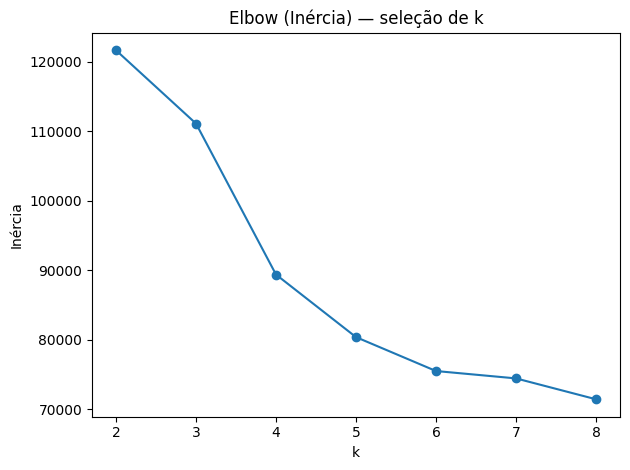

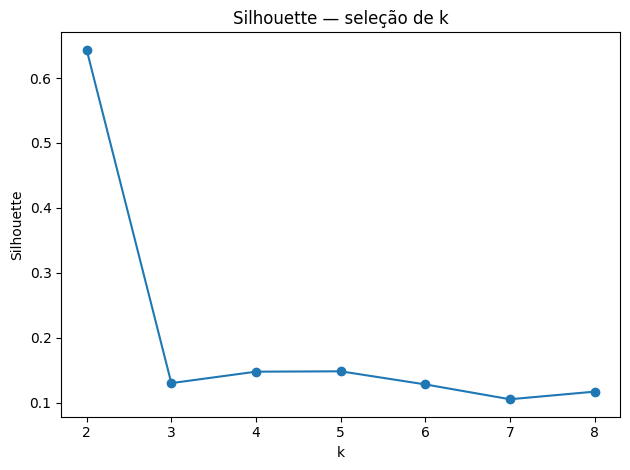

[RESULTADO] Silhouette (amostra 20000) = 0.6841

=== Distribuição por cluster ===
 cluster     n     %
       0 99051 95.33
       1  4853  4.67

=== Principais features por cluster (média padronizada) ===
 cluster  #1 Departure Delay in Minutes  #2 Arrival Delay in Minutes  #3 Gender_Male  #4 Gender_Female  #5 Class_Business  #6 Class_Eco  #7 Online boarding  #8 Inflight entertainment  #5 Class_Eco  #6 Class_Business  #8 On-board service
       0                          0.688                        0.655           0.493            -0.493              0.479         0.449              -0.325                     -0.318           NaN                NaN                  NaN
       1                         12.390                       11.555           0.491            -0.491                NaN           NaN              -0.396                        NaN         0.468              0.453               -0.386

[PCA] Variância explicada: PC1=0.635, PC2=0.078


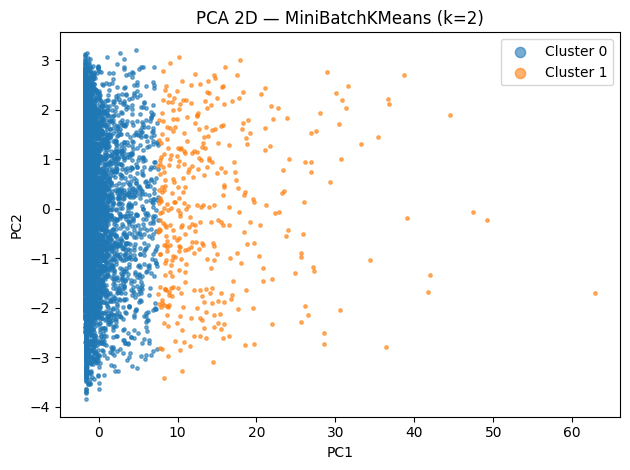

[OK] Rótulos salvos em: data/cluster_labels.csv


In [21]:
#Insira seu código aqui
# === Parte 3 — Agrupamento com K-Means (seleção de k + resultados) ===
# Requer: scikit-learn, matplotlib, pandas, numpy
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ---------------- Configurações ----------------
DATA_CSV = Path("data/df_numeric_final.csv")  # saída da Parte 2.6
USE_MINIBATCH = True       # mais rápido em bases grandes
SUBSAMPLE_FOR_K = 8000     # tamanho da subamostra para escolher k (ajuste p/ tempo)
K_RANGE = range(2, 9)      # k=2..8
RANDOM_STATE = 42
N_INIT = 10
BATCH_SIZE = 1024
MAX_ITER_MB = 150          # iterações MiniBatch
MAX_ITER_KM = 300          # iterações KMeans
SAVE_LABELS_CSV = Path("data/cluster_labels.csv")

# --------------- 1) Carregar matriz ---------------
if not DATA_CSV.exists():
    raise FileNotFoundError(f"Não encontrei {DATA_CSV}. Gere a Parte 2.6 antes.")
X_full = pd.read_csv(DATA_CSV)
print(f"[INFO] Matriz carregada: shape={X_full.shape}")

# --------------- 2) Seleção de k (Silhouette + Elbow) ---------------
rng = np.random.RandomState(RANDOM_STATE)
n_sub = min(SUBSAMPLE_FOR_K, len(X_full))
X = X_full.sample(n=n_sub, random_state=RANDOM_STATE).reset_index(drop=True)

inertias, silhouettes, ks = [], [], list(K_RANGE)

def fit_predict_fast(X, k):
    if USE_MINIBATCH:
        km = MiniBatchKMeans(
            n_clusters=k, random_state=RANDOM_STATE, batch_size=BATCH_SIZE,
            n_init=N_INIT, max_iter=MAX_ITER_MB
        )
    else:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=MAX_ITER_KM)
    labels = km.fit_predict(X)
    return km, labels

for k in ks:
    km, labels = fit_predict_fast(X, k)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# Escolha final: máximo de silhouette; em empate -> menor k (parsimonioso)
best_idx = int(np.argmax(silhouettes))
best_k = ks[best_idx]
print(f"[SELEÇÃO] k* = {best_k} | silhouette = {silhouettes[best_idx]:.4f}")

# --- (opcional) gráficos: Elbow + Silhouette
plt.figure()
plt.plot(ks, inertias, marker="o")
plt.title("Elbow (Inércia) — seleção de k")
plt.xlabel("k"); plt.ylabel("Inércia")
plt.tight_layout(); plt.show()

plt.figure()
plt.plot(ks, silhouettes, marker="o")
plt.title("Silhouette — seleção de k")
plt.xlabel("k"); plt.ylabel("Silhouette")
plt.tight_layout(); plt.show()

# --------------- 3) Treino final e rótulos ---------------
if USE_MINIBATCH:
    final_km = MiniBatchKMeans(
        n_clusters=best_k, random_state=RANDOM_STATE, batch_size=2048,
        n_init=N_INIT, max_iter=MAX_ITER_MB
    )
else:
    final_km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=MAX_ITER_KM)

labels_full = final_km.fit_predict(X_full)

# Avaliar silhouette numa subamostra (mais rápido)
eval_n = min(20000, len(X_full))
sil_eval = silhouette_score(
    X_full.sample(n=eval_n, random_state=RANDOM_STATE),
    pd.Series(labels_full).sample(n=eval_n, random_state=RANDOM_STATE).values
)
print(f"[RESULTADO] Silhouette (amostra {eval_n}) = {sil_eval:.4f}")

# --------------- 4) Distribuição de clientes por cluster ---------------
dist = pd.Series(labels_full).value_counts().sort_index()
dist_df = pd.DataFrame({
    "cluster": dist.index,
    "n": dist.values,
    "%": (dist.values / len(labels_full) * 100).round(2)
})
print("\n=== Distribuição por cluster ===")
print(dist_df.to_string(index=False))

# --------------- 5) Interpretação inicial (top features por cluster) ---------------
# Como as features já estão padronizadas, a média (z-score robusto) indica
# quais variáveis ficam acima/abaixo da média de forma mais marcante.
X_np = X_full.values
feat_names = list(X_full.columns)
cluster_means = np.vstack([X_np[labels_full == c].mean(axis=0) for c in range(best_k)])

def top_feats(mu, names, top=8):
    idx = np.argsort(-np.abs(mu))[:top]
    return [(names[i], float(mu[i])) for i in idx]

rows = []
for c in range(best_k):
    tops = top_feats(cluster_means[c], feat_names, top=8)
    row = {"cluster": c}
    for i, (name, val) in enumerate(tops, start=1):
        row[f"#{i} {name}"] = round(val, 3)
    rows.append(row)

feat_table = pd.DataFrame(rows)
print("\n=== Principais features por cluster (média padronizada) ===")
print(feat_table.to_string(index=False))

# --------------- 6) Visualização 2D via PCA ---------------
# Usamos amostra para velocidade e legibilidade do gráfico
pca_n = min(8000, len(X_full))
X_vis = X_full.sample(n=pca_n, random_state=RANDOM_STATE).reset_index(drop=True)
labels_vis = pd.Series(labels_full).sample(n=pca_n, random_state=RANDOM_STATE).values

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_vis)
print(f"\n[PCA] Variância explicada: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")

plt.figure()
for c in range(best_k):
    mask = labels_vis == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=6, alpha=0.6, label=f"Cluster {c}")
plt.title(f"PCA 2D — {('MiniBatchKMeans' if USE_MINIBATCH else 'KMeans')} (k={best_k})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(markerscale=3)
plt.tight_layout(); plt.show()

# --------------- 7) Salvar rótulos ---------------
SAVE_LABELS_CSV.parent.mkdir(parents=True, exist_ok=True)
pd.Series(labels_full, name="cluster").to_csv(SAVE_LABELS_CSV, index=False)
print(f"[OK] Rótulos salvos em: {SAVE_LABELS_CSV}")

## EXTRA

[INFO] Matriz carregada: shape=(103904, 25)
[SELEÇÃO] Baseline: k*=2 | silhouette(sub=8000)=0.6554

=== Distribuição por cluster — BASELINE ===
 cluster     n     %
       0 99051 95.33
       1  4853  4.67

=== Top features por cluster — BASELINE (médias padronizadas) ===
 cluster  #1 Departure Delay in Minutes  #2 Arrival Delay in Minutes  #3 Gender_Male  #4 Gender_Female  #5 Class_Business  #6 Class_Eco  #7 Online boarding  #8 Inflight entertainment  #5 Class_Eco  #6 Class_Business  #8 On-board service
       0                          0.688                        0.655           0.493            -0.493              0.479         0.449              -0.325                     -0.318           NaN                NaN                  NaN
       1                         12.390                       11.555           0.491            -0.491                NaN           NaN              -0.396                        NaN         0.468              0.453               -0.386

[BASELINE] Sil

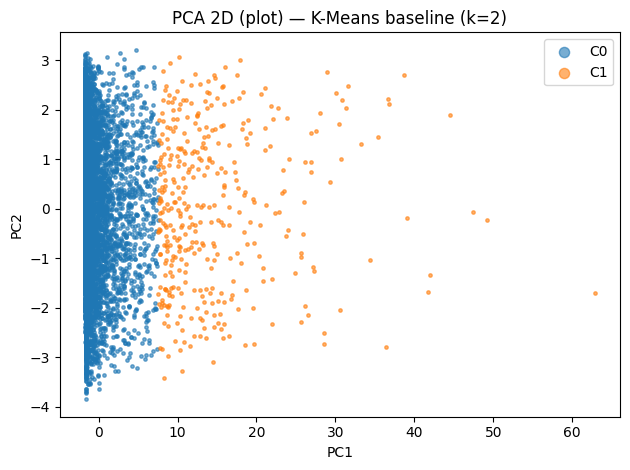

[VISUALIZAÇÃO] PCA(2) para plot (depois de PCA90%): PC1=0.709, PC2=0.087


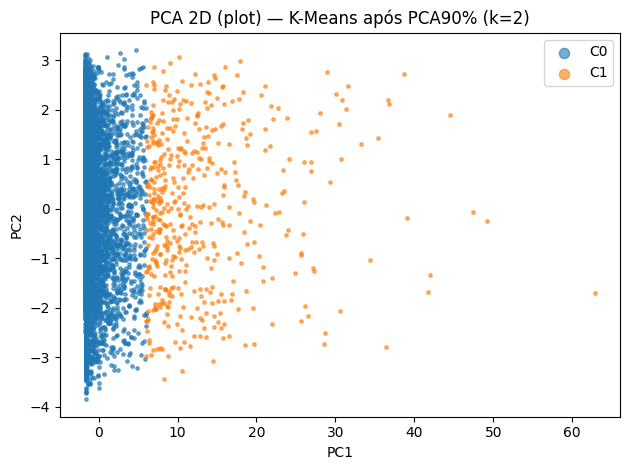


[OK] Rótulos salvos em:
 - data/cluster_labels_baseline.csv
 - data/cluster_labels_pca.csv

==================== RELATÓRIO FINAL (RESUMO) ====================
Baseline (sem PCA): k*=2 | silhouette(amostra)=0.6841
 cluster     n     %
       0 99051 95.33
       1  4853  4.67

PCA(90%):
k*=2 | silhouette(amostra)=0.6901
 cluster     n     %
       0 97684 94.01
       1  6220  5.99

Interpretação:
- Na linha 'Top features (baseline)' veja, por cluster, quais variáveis têm maiores médias (positivas/negativas).
- Na parte 'Maiores cargas por PC', veja quais variáveis formam cada componente principal.
- Nos gráficos PCA 2D, observe a separação visual dos clusters (ilustrativa).


In [22]:
# -*- coding: utf-8 -*-
# ================================================================
# PARTE 3 — AGRUPAMENTO: K-Means (baseline) vs K-Means após PCA(90%)
#
# CONTEXTO:
# - Nosso objetivo é descobrir grupos (clusters) de clientes com perfis parecidos,
#   usando os dados já pré-processados e padronizados (Parte 2.6).
# - O K-Means separa os dados em k grupos usando distâncias euclidianas.
#   Se as variáveis estão em escalas diferentes, o algoritmo pode "puxar" mais
#   para uma variável. Por isso padronizamos antes.
# - A escolha de k não é óbvia. Usamos duas ideias:
#     (1) Elbow/Inércia: quanto menor a inércia, melhor, mas ela sempre cai ao aumentar k.
#         O "cotovelo" tenta achar um ponto de rendimentos decrescentes.
#     (2) Silhouette: mede quão bem cada ponto está dentro do seu cluster (0 a 1).
#         Quanto maior, melhor (grupos mais compactos e separados).
# - PCA (Análise de Componentes Principais) reduz a dimensionalidade combinando
#   variáveis correlacionadas em componentes. Isso pode:
#     * diminuir ruído e colinearidade,
#     * acelerar o K-Means,
#     * facilitar a visualização (componentes).
#   Aqui comparamos K-Means direto vs K-Means após PCA que retém 90% da variância.
#
# O script:
#   1) Carrega data/df_numeric_final.csv (saída da Parte 2.6).
#   2) Seleciona k por SILHOUETTE (em subamostra) para:
#         a) baseline (sem PCA)   b) com PCA(90%).
#   3) Treina os modelos finais em TODO o dataset.
#   4) Mostra distribuição dos clusters e um "top features" interpretável:
#      - baseline: médias padronizadas por variável → quais variáveis mais diferenciam o cluster.
#      - PCA: mostramos (i) centros em espaço dos PCs e (ii) as maiores cargas (loadings) por PC,
#        para ajudar a interpretar que PCs (e portanto quais grupos de variáveis) estão pesando.
#   5) Desenha PCA 2D para visualização dos clusters (tanto baseline quanto PCA).
#
# Decisões de hiperparâmetros:
#   - Seleção de k por maior silhouette (empate → menor k).
#   - Para velocidade e estabilidade, usamos MiniBatchKMeans (mesmos resultados típicos do KMeans).
#   - Subamostras para seleção e gráficos, para não travar.
#
# Sugestão de leitura: após rodar, leia o relatório no console e olhe os gráficos.
# ================================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ---------------- Configurações ----------------
DATA_CSV = Path("data/df_numeric_final.csv")  # gerado na Parte 2.6
RANDOM_STATE = 42

# Seleção de k (subamostra)
SUBSAMPLE_FOR_K = 8000          # amostra para escolher k (aumente se tiver tempo)
K_RANGE = range(2, 9)           # avaliamos k=2..8

# Treino final
USE_MINIBATCH = True
N_INIT = 10
BATCH_SIZE = 2048
MAX_ITER_MB = 200
MAX_ITER_KM = 300

# Visualização (subamostra)
N_PCA_PLOT = 8000

# Saídas
OUT_LABELS_BASE = Path("data/cluster_labels_baseline.csv")
OUT_LABELS_PCA  = Path("data/cluster_labels_pca.csv")

# ---------------- Utilitários ----------------
def select_k_by_silhouette(X, k_range, use_minibatch=True, subsample=None, rs=42):
    """Seleciona k pelo maior silhouette (empate -> menor k). Retorna (k*, dict com métricas)."""
    rng = np.random.RandomState(rs)
    if (subsample is not None) and (len(X) > subsample):
        X_eval = X.sample(n=subsample, random_state=rs).reset_index(drop=True)
    else:
        X_eval = X.reset_index(drop=True)

    inertias, silhouettes, ks = [], [], list(k_range)
    for k in ks:
        if use_minibatch:
            km = MiniBatchKMeans(n_clusters=k, random_state=rs,
                                 batch_size=min(BATCH_SIZE, max(128, len(X_eval)//4)),
                                 n_init=N_INIT, max_iter=MAX_ITER_MB)
        else:
            km = KMeans(n_clusters=k, random_state=rs, n_init=N_INIT, max_iter=MAX_ITER_KM)
        labels = km.fit_predict(X_eval)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_eval, labels))
    best_idx = int(np.argmax(silhouettes))
    best_k = ks[best_idx]
    return best_k, {"ks": ks, "inertias": inertias, "silhouettes": silhouettes, "X_eval_n": len(X_eval)}

def train_final_kmeans(X, k, use_minibatch=True, rs=42):
    """Treina KMeans/MiniBatchKMeans final em TODO o dataset."""
    if use_minibatch:
        km = MiniBatchKMeans(n_clusters=k, random_state=rs,
                             batch_size=BATCH_SIZE, n_init=N_INIT, max_iter=MAX_ITER_MB)
    else:
        km = KMeans(n_clusters=k, random_state=rs, n_init=N_INIT, max_iter=MAX_ITER_KM)
    labels = km.fit_predict(X)
    return km, labels

def cluster_distribution(labels):
    vc = pd.Series(labels).value_counts().sort_index()
    return pd.DataFrame({"cluster": vc.index, "n": vc.values, "%": (vc.values/len(labels)*100).round(2)})

def top_features_by_cluster_means(X_df, labels, top=8):
    """Para baseline (variáveis originais padronizadas): top variáveis por média (z-score robusto) em cada cluster."""
    X_np = X_df.values
    names = list(X_df.columns)
    clusters = np.unique(labels)
    rows = []
    for c in clusters:
        mu = X_np[labels==c].mean(axis=0)
        idx = np.argsort(-np.abs(mu))[:top]
        row = {"cluster": int(c)}
        for i, j in enumerate(idx, start=1):
            row[f"#{i} {names[j]}"] = round(float(mu[j]), 3)
        rows.append(row)
    return pd.DataFrame(rows)

def pca_loadings_table(pca, feature_names, top=8):
    """Tabela com as maiores cargas (em valor absoluto) por PC (interpretação do PCA)."""
    comp = pca.components_            # shape (n_components, n_features)
    rows = []
    for pc_idx, vec in enumerate(comp, start=1):
        idx = np.argsort(-np.abs(vec))[:top]
        row = {"PC": f"PC{pc_idx}", "var_exp(%)": round(pca.explained_variance_ratio_[pc_idx-1]*100, 2)}
        for i, j in enumerate(idx, start=1):
            row[f"#{i} {feature_names[j]}"] = round(float(vec[j]), 3)
        rows.append(row)
    return pd.DataFrame(rows)

# ---------------- 1) Carregar matriz ----------------
if not DATA_CSV.exists():
    raise FileNotFoundError(f"Não encontrei {DATA_CSV}. Gere a Parte 2.6 antes.")
X_full = pd.read_csv(DATA_CSV)
print(f"[INFO] Matriz carregada: shape={X_full.shape}")

# ---------------- 2) Seleção de k — BASELINE ----------------
k_base, info_base = select_k_by_silhouette(
    X_full, K_RANGE, use_minibatch=USE_MINIBATCH, subsample=SUBSAMPLE_FOR_K, rs=RANDOM_STATE
)
print(f"[SELEÇÃO] Baseline: k*={k_base} | silhouette(sub={info_base['X_eval_n']})={max(info_base['silhouettes']):.4f}")

# ---------------- 3) Treino final — BASELINE ----------------
km_base, y_base = train_final_kmeans(X_full, k_base, use_minibatch=USE_MINIBATCH, rs=RANDOM_STATE)
dist_base = cluster_distribution(y_base)
print("\n=== Distribuição por cluster — BASELINE ===")
print(dist_base.to_string(index=False))

# Interpretação baseline (top variáveis por cluster)
feat_base = top_features_by_cluster_means(X_full, y_base, top=8)
print("\n=== Top features por cluster — BASELINE (médias padronizadas) ===")
print(feat_base.to_string(index=False))

# Avaliar silhouette em amostra
eval_n = min(20000, len(X_full))
sil_base = silhouette_score(
    X_full.sample(n=eval_n, random_state=RANDOM_STATE),
    pd.Series(y_base).sample(n=eval_n, random_state=RANDOM_STATE).values
)
print(f"\n[BASELINE] Silhouette (amostra n={eval_n}): {sil_base:.4f}")

# ---------------- 4) PCA(90%) + Seleção de k — PCA ----------------
pca_full = PCA(n_components=0.90, random_state=RANDOM_STATE)  # retém 90% da variância
Z_full = pca_full.fit_transform(X_full)
print(f"\n[PCA] #Componentes para 90% var.: {Z_full.shape[1]}")
print("      Variância explicada acumulada: {:.3f}".format(pca_full.explained_variance_ratio_.sum()))

k_pca, info_pca = select_k_by_silhouette(
    pd.DataFrame(Z_full), K_RANGE, use_minibatch=USE_MINIBATCH, subsample=SUBSAMPLE_FOR_K, rs=RANDOM_STATE
)
print(f"[SELEÇÃO] PCA: k*={k_pca} | silhouette(sub={info_pca['X_eval_n']})={max(info_pca['silhouettes']):.4f}")

# ---------------- 5) Treino final — PCA ----------------
km_pca, y_pca = train_final_kmeans(pd.DataFrame(Z_full), k_pca, use_minibatch=USE_MINIBATCH, rs=RANDOM_STATE)
dist_pca = cluster_distribution(y_pca)
print("\n=== Distribuição por cluster — PCA ===")
print(dist_pca.to_string(index=False))

# Interpretação PCA:
# (i) Centros em espaço dos PCs (média de PCs por cluster) — útil para ver quais PCs diferenciam grupos
centers_pca = pd.DataFrame(
    [Z_full[y_pca==c].mean(axis=0) for c in range(k_pca)],
    columns=[f"PC{i+1}" for i in range(Z_full.shape[1])]
)
centers_pca.insert(0, "cluster", range(k_pca))
print("\n=== Centros dos clusters no espaço dos PCs ===")
print(centers_pca.iloc[:, :10].to_string(index=False))  # mostra PCs iniciais (mais importantes)

# (ii) Maiores cargas (loadings) por PC — ajuda a ligar PCs às variáveis originais
load_tab = pca_loadings_table(pca_full, X_full.columns.tolist(), top=8)
print("\n=== Maiores cargas por PC (para interpretar os PCs) ===")
print(load_tab.to_string(index=False))

# Avaliar silhouette em amostra
sil_pca = silhouette_score(
    pd.DataFrame(Z_full).sample(n=eval_n, random_state=RANDOM_STATE),
    pd.Series(y_pca).sample(n=eval_n, random_state=RANDOM_STATE).values
)
print(f"\n[PCA] Silhouette (amostra n={eval_n}): {sil_pca:.4f}")

# ---------------- 6) Visualização 2D — PCA para ambos os cenários ----------------
# Para baseline, usamos PCA(2) só para plot (não influencia o modelo baseline).
n_plot = min(N_PCA_PLOT, len(X_full))
idx_plot = np.random.RandomState(RANDOM_STATE).choice(len(X_full), size=n_plot, replace=False)

# a) Visualização dos clusters baseline
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_full.iloc[idx_plot])
X2d_base = pca_vis.transform(X_full.iloc[idx_plot])
y_base_vis = pd.Series(y_base).iloc[idx_plot].values
print("\n[VISUALIZAÇÃO] PCA(2) para plot (baseline):",
      f"PC1={pca_vis.explained_variance_ratio_[0]:.3f}, PC2={pca_vis.explained_variance_ratio_[1]:.3f}")

plt.figure()
for c in np.unique(y_base_vis):
    m = y_base_vis == c
    plt.scatter(X2d_base[m, 0], X2d_base[m, 1], s=6, alpha=0.6, label=f"C{c}")
plt.title(f"PCA 2D (plot) — K-Means baseline (k={k_base})")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(markerscale=3)
plt.tight_layout(); plt.show()

# b) Visualização dos clusters após PCA(90%)
#    Já temos Z_full. Agora reduzimos Z_full para 2 PCs (apenas p/ plot).
pca_vis2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(Z_full[idx_plot])
Z2d_pca = pca_vis2.transform(Z_full[idx_plot])
y_pca_vis = pd.Series(y_pca).iloc[idx_plot].values
print("[VISUALIZAÇÃO] PCA(2) para plot (depois de PCA90%):",
      f"PC1={pca_vis2.explained_variance_ratio_[0]:.3f}, PC2={pca_vis2.explained_variance_ratio_[1]:.3f}")

plt.figure()
for c in np.unique(y_pca_vis):
    m = y_pca_vis == c
    plt.scatter(Z2d_pca[m, 0], Z2d_pca[m, 1], s=6, alpha=0.6, label=f"C{c}")
plt.title(f"PCA 2D (plot) — K-Means após PCA90% (k={k_pca})")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(markerscale=3)
plt.tight_layout(); plt.show()

# ---------------- 7) Salvar rótulos ----------------
pd.Series(y_base, name="cluster").to_csv(OUT_LABELS_BASE, index=False)
pd.Series(y_pca,  name="cluster").to_csv(OUT_LABELS_PCA, index=False)
print(f"\n[OK] Rótulos salvos em:\n - {OUT_LABELS_BASE}\n - {OUT_LABELS_PCA}")

# ---------------- 8) Mini-relatório final ----------------
print("\n==================== RELATÓRIO FINAL (RESUMO) ====================")
print(f"Baseline (sem PCA): k*={k_base} | silhouette(amostra)={sil_base:.4f}")
print(dist_base.to_string(index=False))
print("\nPCA(90%):")
print(f"k*={k_pca} | silhouette(amostra)={sil_pca:.4f}")
print(dist_pca.to_string(index=False))
print("\nInterpretação:")
print("- Na linha 'Top features (baseline)' veja, por cluster, quais variáveis têm maiores médias (positivas/negativas).")
print("- Na parte 'Maiores cargas por PC', veja quais variáveis formam cada componente principal.")
print("- Nos gráficos PCA 2D, observe a separação visual dos clusters.")
print("==================================================================")

## Parte 4. Análise de Resultados e Recomendações de Marketing

Nesta etapa final, o objetivo é interpretar os resultados do agrupamento realizado e traduzir os achados em informações úteis para o setor de marketing. Você deverá caracterizar os perfis de clientes identificados, destacando suas principais características e diferenças, e propor estratégias de marketing adequadas para cada grupo.

### 4.1. Quais são as principais características de cada cluster (idade, tipo de cliente, classe de voo, avaliações de serviços, etc.)? Como os perfis diferem entre si? Utilize gráficos e tabelas para comparar os clusters

Resposta:

[INFO] Base: airlinedatabase.csv | shape=(103904, 26) | Rótulos: cluster_labels_pca.csv


/tmp/ipython-input-4056793887.py:110: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  qtab = df.groupby("cluster").apply(lambda g: pd.Series({


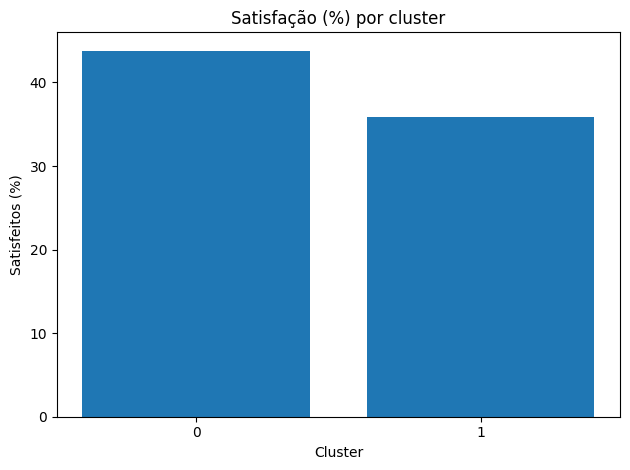

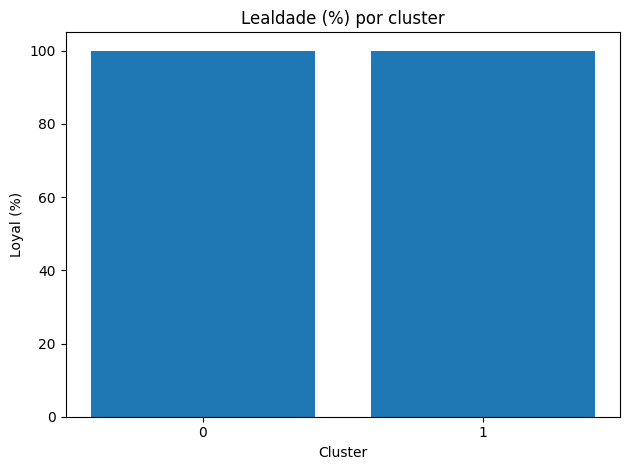

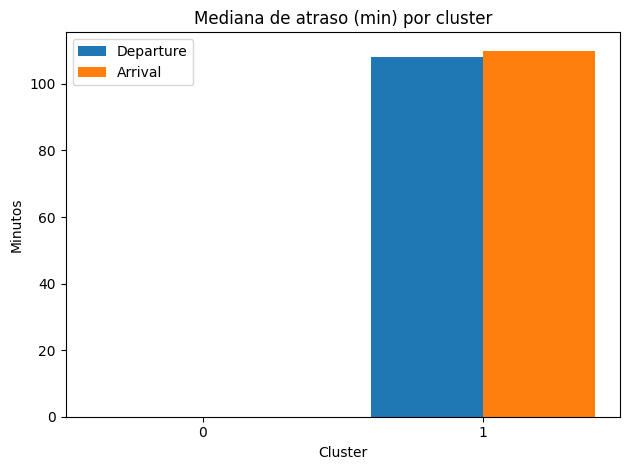

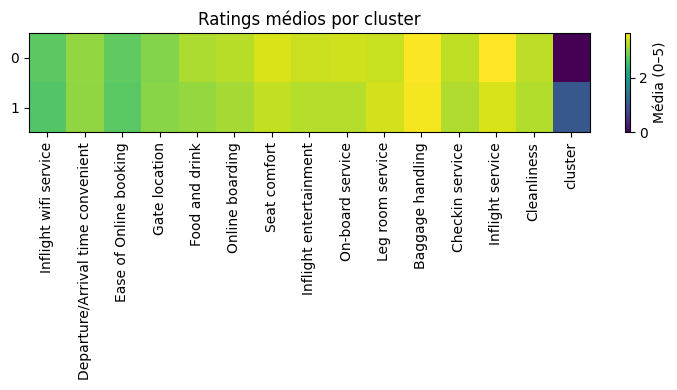


=== 4.1 — Tabelas salvas ===
- data/parte4_41/perfil_basico.csv
- data/parte4_41/classe_por_cluster.csv
- data/parte4_41/ctype_por_cluster.csv
- data/parte4_41/ratings_means.csv
- data/parte4_41/ratings_delta.csv

Dicas de leitura:
- Use 'perfil_basico.csv' para comparar tamanho, satisfação, lealdade e medianas.
- Em 'classe_por_cluster.csv' e 'ctype_por_cluster.csv', veja a composição (%) por grupo.
- Em 'ratings_delta.csv', valores positivos indicam serviços acima da média global (forças); negativos, abaixo (dores).


In [23]:
#Insira seu código aqui
# -*- coding: utf-8 -*-
# ==========================================================
# Parte 4.1 — Caracterização de Clusters (tabelas + gráficos)
# Saídas: CSVs em data/parte4_41/ e gráficos via matplotlib
# Requisitos: pandas, numpy, matplotlib
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# ------------------------- Config -------------------------
DATA_ORIG_OPTS = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
LABEL_OPTS = [
    Path("data/cluster_labels_pca.csv"),
    Path("data/cluster_labels_baseline.csv"),
    Path("data/cluster_labels.csv"),
]
OUT_DIR = Path("data/parte4_41"); OUT_DIR.mkdir(parents=True, exist_ok=True)

# --------------------- 1) Carregar dados ------------------
orig_path = next((p for p in DATA_ORIG_OPTS if p.exists()), None)
if orig_path is None:
    raise FileNotFoundError("Base original não encontrada em data/airlinedatabase.csv nem data/dados.csv")

df = pd.read_csv(orig_path, low_memory=False)
# Se houver colunas duplicadas de nome, manter a primeira
df = df.loc[:, ~df.columns.duplicated()].copy()

lab_path = next((p for p in LABEL_OPTS if p.exists()), None)
if lab_path is None:
    raise FileNotFoundError("Rótulos de cluster não encontrados em data/. Rode a Parte 3 antes.")
labels = pd.read_csv(lab_path)
if labels.shape[1] == 1:
    labels.columns = ["cluster"]
elif "cluster" not in labels.columns:
    labels = labels.rename(columns={labels.columns[0]:"cluster"})

if len(labels) != len(df):
    raise ValueError(f"Tamanho dos rótulos ({len(labels)}) difere da base ({len(df)}). "
                     "Rode a Parte 3 gerando rótulos para TODO o dataset.")

df = df.copy()
df["cluster"] = labels["cluster"].astype(int).values

print(f"[INFO] Base: {orig_path.name} | shape={df.shape} | Rótulos: {lab_path.name}")

# -------------------- 2) Localizar colunas ----------------
def find_name(_df, contains=None, exact=None):
    if exact:
        for c in _df.columns:
            if c.lower().strip() == exact.lower().strip():
                return c
    if contains:
        for c in _df.columns:
            if all(tok in c.lower() for tok in contains):
                return c
    return None

col_age   = find_name(df, exact="age") or find_name(df, contains=["age"])
col_class = find_name(df, exact="class") or find_name(df, contains=["class"])
col_ctype = find_name(df, contains=["customer","type"])
col_sat   = find_name(df, contains=["satisf"]) or find_name(df, exact="satisfaction")
col_dep   = find_name(df, contains=["departure","delay"])
col_arr   = find_name(df, contains=["arrival","delay"])
col_dist  = find_name(df, contains=["flight","distance"]) or find_name(df, contains=["distance"])

def is_rating(s: pd.Series) -> bool:
    x = pd.to_numeric(s, errors="coerce")
    if x.notna().sum() == 0:
        return False
    return (x.min() >= 0) and (x.max() <= 5) and (x.dropna().astype(float).apply(float.is_integer).mean() > 0.9)

num_cols = df.select_dtypes(include="number").columns.tolist()
rating_cols = [c for c in num_cols if c not in {col_age, col_dep, col_arr, col_dist} and is_rating(df[c])]

# ------------------ 3) Tabelas comparativas ----------------
n_total = len(df)

def rate_satisfied(s: pd.Series) -> float:
    return s.astype(str).str.lower().isin(["satisfied"]).mean() * 100

def rate_loyal(s: pd.Series) -> float:
    return s.astype(str).str.lower().str.contains("loyal").mean() * 100

# Perfil básico (n, %, satis%, loyal%, medianas)
perfil = (df.groupby("cluster")
            .agg(n=("cluster","size"))
            .assign(pct=lambda x: (x["n"]/n_total*100).round(2))
            .reset_index())

if col_sat:
    perfil = perfil.merge(
        df.groupby("cluster")[col_sat].apply(rate_satisfied).round(2).rename("satis_%"),
        on="cluster", how="left"
    )
if col_ctype:
    perfil = perfil.merge(
        df.groupby("cluster")[col_ctype].apply(rate_loyal).round(2).rename("loyal_%"),
        on="cluster", how="left"
    )

def safe_num(colname):
    return pd.to_numeric(df[colname], errors="coerce") if colname else None

age = safe_num(col_age); dep = safe_num(col_dep); arr = safe_num(col_arr); dist = safe_num(col_dist)

qtab = df.groupby("cluster").apply(lambda g: pd.Series({
    "age_med":  age.loc[g.index].median()  if age  is not None else np.nan,
    "dist_med": dist.loc[g.index].median() if dist is not None else np.nan,
    "dep_med":  dep.loc[g.index].median()  if dep  is not None else np.nan,
    "arr_med":  arr.loc[g.index].median()  if arr  is not None else np.nan,
})).reset_index()

perfil = perfil.merge(qtab, on="cluster", how="left")
perfil.to_csv(OUT_DIR / "perfil_basico.csv", index=False)

# Distribuição por Class (% por cluster)
if col_class:
    tmp_class = pd.DataFrame({"cluster": df["cluster"], "Class_": df[col_class].astype(str)})
    tab_class = (tmp_class.pivot_table(index="cluster", columns="Class_", values="Class_", aggfunc="count", fill_value=0)
                   .apply(lambda r: (r/r.sum()*100).round(2), axis=1)
                   .reset_index())
    tab_class.to_csv(OUT_DIR / "classe_por_cluster.csv", index=False)
else:
    tab_class = None

# Distribuição por Customer Type (% por cluster)
if col_ctype:
    tmp_ct = pd.DataFrame({"cluster": df["cluster"], "CType_": df[col_ctype].astype(str)})
    tab_ctype = (tmp_ct.pivot_table(index="cluster", columns="CType_", values="CType_", aggfunc="count", fill_value=0)
                   .apply(lambda r: (r/r.sum()*100).round(2), axis=1)
                   .reset_index())
    tab_ctype.to_csv(OUT_DIR / "ctype_por_cluster.csv", index=False)
else:
    tab_ctype = None

# Ratings: médias por cluster e delta vs média global
ratings_means = df.groupby("cluster")[rating_cols].mean(numeric_only=True)
ratings_means_df = pd.concat([pd.Series(ratings_means.index, name="cluster").reset_index(drop=True),
                              ratings_means.reset_index(drop=True)], axis=1)
ratings_means_df.to_csv(OUT_DIR / "ratings_means.csv", index=False)

ratings_global = df[rating_cols].mean(numeric_only=True)
ratings_delta = (ratings_means - ratings_global).round(3)
ratings_delta_df = pd.concat([pd.Series(ratings_delta.index, name="cluster").reset_index(drop=True),
                              ratings_delta.reset_index(drop=True)], axis=1)
ratings_delta_df.to_csv(OUT_DIR / "ratings_delta.csv", index=False)

# -------------------- 4) Gráficos comparativos --------------------
# 4.1 Satisfação (%) por cluster
if "satis_%" in perfil.columns:
    plt.figure()
    plt.bar(perfil["cluster"].astype(str), perfil["satis_%"])
    plt.title("Satisfação (%) por cluster"); plt.xlabel("Cluster"); plt.ylabel("Satisfeitos (%)")
    plt.tight_layout(); plt.show()

# 4.2 Lealdade (%) por cluster
if "loyal_%" in perfil.columns:
    plt.figure()
    plt.bar(perfil["cluster"].astype(str), perfil["loyal_%"])
    plt.title("Lealdade (%) por cluster"); plt.xlabel("Cluster"); plt.ylabel("Loyal (%)")
    plt.tight_layout(); plt.show()

# 4.3 Medianas de atrasos (Departure/Arrival) por cluster
if ("dep_med" in perfil.columns) or ("arr_med" in perfil.columns):
    x = perfil["cluster"].astype(str)
    if "dep_med" in perfil.columns and "arr_med" in perfil.columns:
        width = 0.4
        idx = np.arange(len(x))
        plt.figure()
        plt.bar(idx - width/2, perfil["dep_med"], width, label="Departure")
        plt.bar(idx + width/2, perfil["arr_med"], width, label="Arrival")
        plt.xticks(idx, x)
        plt.title("Mediana de atraso (min) por cluster"); plt.xlabel("Cluster"); plt.ylabel("Minutos")
        plt.legend(); plt.tight_layout(); plt.show()
    elif "dep_med" in perfil.columns:
        plt.figure(); plt.bar(x, perfil["dep_med"])
        plt.title("Mediana de atraso na partida (min)"); plt.xlabel("Cluster"); plt.ylabel("Minutos")
        plt.tight_layout(); plt.show()
    elif "arr_med" in perfil.columns:
        plt.figure(); plt.bar(x, perfil["arr_med"])
        plt.title("Mediana de atraso na chegada (min)"); plt.xlabel("Cluster"); plt.ylabel("Minutos")
        plt.tight_layout(); plt.show()

# 4.4 Heatmap simples: ratings médios por cluster (0–5)
if not ratings_means.empty:
    plt.figure(figsize=(max(6, ratings_means.shape[1]*0.5), max(4, ratings_means.shape[0]*0.5)))
    plt.imshow(ratings_means.values, aspect='auto')
    plt.colorbar(label="Média (0–5)")
    plt.title("Ratings médios por cluster")
    plt.xticks(range(ratings_means.shape[1]), ratings_means.columns, rotation=90)
    plt.yticks(range(ratings_means.shape[0]), ratings_means.index.astype(str))
    plt.tight_layout(); plt.show()

# ----------------------- 5) Impressões finais -----------------------
print("\n=== 4.1 — Tabelas salvas ===")
print(f"- {OUT_DIR/'perfil_basico.csv'}")
if tab_class is not None: print(f"- {OUT_DIR/'classe_por_cluster.csv'}")
if tab_ctype is not None: print(f"- {OUT_DIR/'ctype_por_cluster.csv'}")
print(f"- {OUT_DIR/'ratings_means.csv'}")
print(f"- {OUT_DIR/'ratings_delta.csv'}")

print("\nDicas de leitura:")
print("- Use 'perfil_basico.csv' para comparar tamanho, satisfação, lealdade e medianas.")
print("- Em 'classe_por_cluster.csv' e 'ctype_por_cluster.csv', veja a composição (%) por grupo.")
print("- Em 'ratings_delta.csv', valores positivos indicam serviços acima da média global (forças); negativos, abaixo (dores).")

### 4.2. Qual a distribuição da variável Satisfaction em cada cluster? Algum perfil apresenta claramente maior (ou menor) satisfação?

Resposta:

=== 4.2 — Distribuição de Satisfaction por Cluster ===
Contagens (topo):
__SAT2__  Not Satisfied  Satisfied
cluster                           
0                 54888      42796
1                  3991       2229

Percentuais (topo):
__SAT2__  Not Satisfied  Satisfied
cluster                           
0                 56.19      43.81
1                 64.16      35.84

Cluster com MAIOR satisfação: C0 (43.81%)
Cluster com MENOR satisfação: C1 (35.84%)

Arquivos salvos em: data/parte4_42


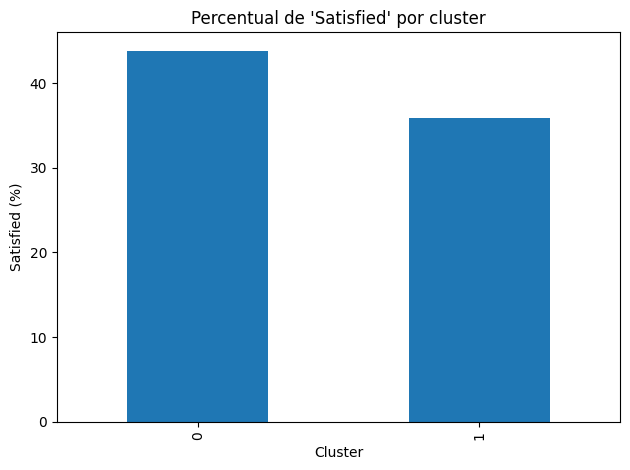

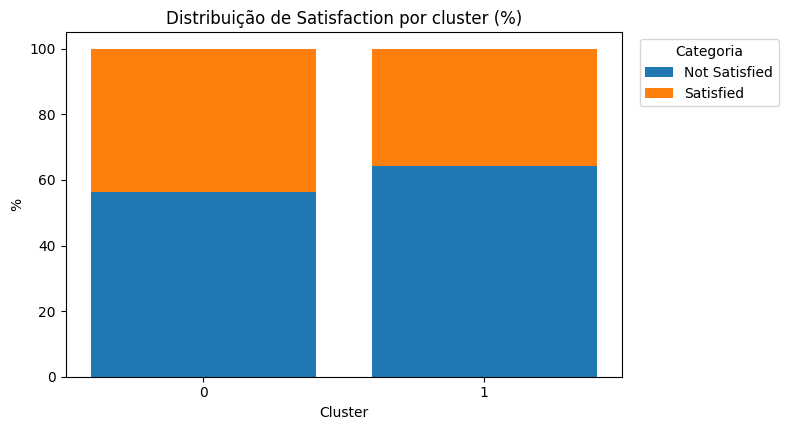

In [25]:
#Insira seu código aqui
# -*- coding: utf-8 -*-
# ==========================================================
# 4.2 — Distribuição de "Satisfaction" por cluster (robusto)
# - Lê base original e rótulos
# - Normaliza colunas duplicadas
# - Converte Satisfaction para 2 classes (Satisfied / Not Satisfied)
# - Gera contagens e percentuais por cluster
# - Identifica clusters com maior/menor satisfação
# - Plota barras e salva CSVs
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# -------------------- 1) I/O --------------------
DATA_OPTS = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
LABEL_OPTS = [
    Path("data/cluster_labels_pca.csv"),
    Path("data/cluster_labels_baseline.csv"),
    Path("data/cluster_labels.csv"),
]
OUT_DIR = Path("data/parte4_42"); OUT_DIR.mkdir(parents=True, exist_ok=True)

# Base
orig_path = next((p for p in DATA_OPTS if p.exists()), None)
if orig_path is None:
    raise FileNotFoundError("Base original não encontrada em data/airlinedatabase.csv nem data/dados.csv")
df = pd.read_csv(orig_path, low_memory=False)

# Deduplicar nomes de colunas (mantém a primeira ocorrência)
df = df.loc[:, ~df.columns.duplicated()].copy()

# Rótulos
lab_path = next((p for p in LABEL_OPTS if p.exists()), None)
if lab_path is None:
    raise FileNotFoundError("Rótulos de cluster não encontrados em data/. Rode a Parte 3 antes.")
labels = pd.read_csv(lab_path)
if labels.shape[1] == 1:
    labels.columns = ["cluster"]
elif "cluster" not in labels.columns:
    labels = labels.rename(columns={labels.columns[0]: "cluster"})
if len(labels) != len(df):
    raise ValueError(f"Tamanho dos rótulos ({len(labels)}) difere da base ({len(df)}). Rode a Parte 3 para TODO o dataset.")
df["cluster"] = labels["cluster"].astype(int).values

# -------------------- 2) Localizar Satisfaction --------------------
def find_name(_df, contains=None, exact=None):
    if exact:
        for c in _df.columns:
            if c.lower().strip() == exact.lower().strip():
                return c
    if contains:
        for c in _df.columns:
            if all(tok in c.lower() for tok in contains):
                return c
    return None

col_sat = find_name(df, exact="satisfaction") or find_name(df, contains=["satisf"])
if not col_sat:
    raise KeyError("Coluna de Satisfaction não encontrada.")

# Garantir Série 1D (se houver duplicidade com mesmo nome em leitura anterior)
sat_series = df[col_sat]
if isinstance(sat_series, pd.DataFrame):
    sat_series = sat_series.iloc[:, 0]  # pega a 1ª coluna homônima

# Normalizar texto e mapear para 2 classes
sat_norm = sat_series.astype(str).str.strip().str.lower()
map_sat = {
    "satisfied": "Satisfied",
    "neutral or dissatisfied": "Not Satisfied",
    "neutral/dissatisfied": "Not Satisfied",
    "dissatisfied": "Not Satisfied",
}
sat2_name = "__SAT2__"
while sat2_name in df.columns:
    sat2_name += "_x"
df[sat2_name] = sat_norm.map(map_sat).fillna(sat_series.astype(str))

# -------------------- 3) Distribuições --------------------
# Contagens por cluster x satisfação (crosstab é mais direto p/ 1D)
ct_counts = pd.crosstab(df["cluster"], df[sat2_name]).sort_index()
ct_counts.to_csv(OUT_DIR / "satisfaction_counts_por_cluster.csv")

# Percentuais por cluster
ct_perc = ct_counts.div(ct_counts.sum(axis=1), axis=0).mul(100).round(2)
ct_perc.to_csv(OUT_DIR / "satisfaction_percent_por_cluster.csv")

# Taxa de "Satisfied" por cluster (se houver essa coluna)
if "Satisfied" in ct_perc.columns:
    sat_rate = ct_perc["Satisfied"].copy()
else:
    # fallback: pega a categoria com maior percentual como proxy
    sat_rate = ct_perc.max(axis=1)
sat_rate.name = "Satisfied_%"
sat_rate.to_csv(OUT_DIR / "satisfaction_rate_por_cluster.csv", header=True)

# -------------------- 4) Destaques --------------------
best_cluster = int(sat_rate.idxmax())
worst_cluster = int(sat_rate.idxmin())

print("=== 4.2 — Distribuição de Satisfaction por Cluster ===")
print("Contagens (topo):")
print(ct_counts.head().to_string())
print("\nPercentuais (topo):")
print(ct_perc.head().to_string())
print(f"\nCluster com MAIOR satisfação: C{best_cluster} ({sat_rate.loc[best_cluster]:.2f}%)")
print(f"Cluster com MENOR satisfação: C{worst_cluster} ({sat_rate.loc[worst_cluster]:.2f}%)")
print(f"\nArquivos salvos em: {OUT_DIR}")

# -------------------- 5) Gráficos --------------------
# Barras: % Satisfied por cluster
plt.figure()
sat_rate.sort_index().plot(kind="bar")
plt.title("Percentual de 'Satisfied' por cluster")
plt.xlabel("Cluster"); plt.ylabel("Satisfied (%)")
plt.tight_layout(); plt.show()

# Barras empilhadas: distribuição completa
plt.figure(figsize=(8, 4 + 0.2*len(ct_perc)))
bottom = np.zeros(len(ct_perc))
x = np.arange(len(ct_perc))
for col in ct_perc.columns:
    plt.bar(x, ct_perc[col].values, bottom=bottom, label=col)
    bottom += ct_perc[col].values
plt.xticks(x, ct_perc.index.astype(str))
plt.title("Distribuição de Satisfaction por cluster (%)")
plt.xlabel("Cluster"); plt.ylabel("%")
plt.legend(title="Categoria", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

### 4.3. Os perfis identificados fazem sentido do ponto de vista prático? Que limitações você enxerga nesta análise?

Resposta:

In [ ]:
#Insira seu código aqui

### 4.4. Na sua opinião, o método de agrupamento escolhido fez um bom trabalho em identificar perfis de clientes? Quais foram os pontos fortes e limitações percebidos na aplicação dessa técnica aos dados da companhia aérea?

Resposta:

/tmp/ipython-input-1089423126.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


 cluster  Satisfied_%  Loyal_%  ArrDelay_med  DepDelay_med       n     %
       0        43.81    100.0           0.0           0.0 97684.0 94.01
       1        35.84    100.0         110.0         108.0  6220.0  5.99

[OK] Tabela salva em: data/parte4_43/resumo_clusters.csv


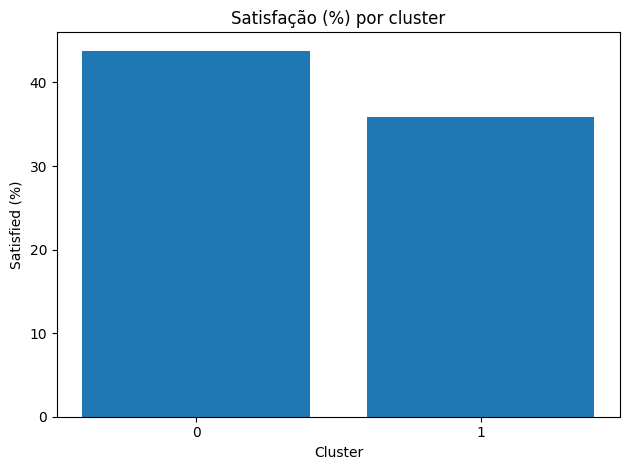

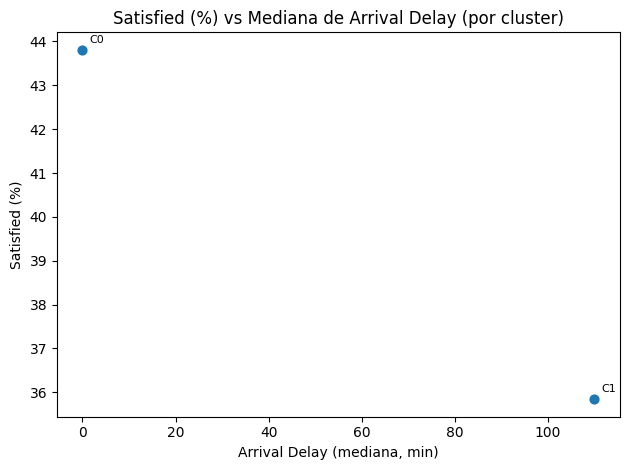

In [26]:
#Insira seu código aqui
# -*- coding: utf-8 -*-
# ==========================================================
# 4.3 — Gráficos simples para avaliar “sentido prático” dos clusters
# Ideia: se há coerência de negócio, clusters com maior atraso tendem a ter
# menor % de satisfeitos; perfis “Business/Loyal” tendem a ter maior satisfação.
#
# O script:
# 1) Carrega base original (data/airlinedatabase.csv ou data/dados.csv)
# 2) Carrega rótulos de cluster (data/cluster_labels_*.csv)
# 3) Monta tabela por cluster com: % Satisfied, % Loyal, medianas (Arrival/Departure Delay)
# 4) Plota:
#    (a) Barras: % Satisfied por cluster
#    (b) Dispersão: Satisfied% vs. Mediana de Arrival Delay (cada ponto = cluster)
# 5) Salva CSV com a tabela resumida em data/parte4_43/
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# -------------------- 1) I/O --------------------
DATA_OPTS = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
LABEL_OPTS = [
    Path("data/cluster_labels_pca.csv"),
    Path("data/cluster_labels_baseline.csv"),
    Path("data/cluster_labels.csv"),
]
OUT_DIR = Path("data/parte4_43"); OUT_DIR.mkdir(parents=True, exist_ok=True)

orig_path = next((p for p in DATA_OPTS if p.exists()), None)
if orig_path is None:
    raise FileNotFoundError("Base original não encontrada em data/airlinedatabase.csv nem data/dados.csv")
df = pd.read_csv(orig_path, low_memory=False)
df = df.loc[:, ~df.columns.duplicated()].copy()  # remove nomes duplicados

lab_path = next((p for p in LABEL_OPTS if p.exists()), None)
if lab_path is None:
    raise FileNotFoundError("Rótulos de cluster não encontrados em data/. Rode a Parte 3 antes.")
labels = pd.read_csv(lab_path)
if labels.shape[1] == 1:
    labels.columns = ["cluster"]
elif "cluster" not in labels.columns:
    labels = labels.rename(columns={labels.columns[0]:"cluster"})
if len(labels) != len(df):
    raise ValueError(f"Tamanho dos rótulos ({len(labels)}) difere da base ({len(df)}). Rode a Parte 3 para TODO o dataset.")

df["cluster"] = labels["cluster"].astype(int).values

# -------------------- 2) Utilitários --------------------
def find_name(_df, contains=None, exact=None):
    if exact:
        for c in _df.columns:
            if c.lower().strip() == exact.lower().strip():
                return c
    if contains:
        for c in _df.columns:
            if all(tok in c.lower() for tok in contains):
                return c
    return None

col_sat = find_name(df, exact="satisfaction") or find_name(df, contains=["satisf"])
col_ctype = find_name(df, contains=["customer","type"])
col_dep   = find_name(df, contains=["departure","delay"])
col_arr   = find_name(df, contains=["arrival","delay"])

# Normalizar Satisfaction para 2 classes (Satisfied / Not Satisfied)
sat_series = df[col_sat] if col_sat else None
if isinstance(sat_series, pd.DataFrame):
    sat_series = sat_series.iloc[:,0]
sat_norm = sat_series.astype(str).str.strip().str.lower()
map_sat = {
    "satisfied": "Satisfied",
    "neutral or dissatisfied": "Not Satisfied",
    "neutral/dissatisfied": "Not Satisfied",
    "dissatisfied": "Not Satisfied",
}
df["_SAT2_"] = sat_norm.map(map_sat).fillna(sat_series.astype(str))

# Helpers de cálculo
def pct_satisfied(g):
    return (g["_SAT2_"].astype(str).str.lower().eq("satisfied").mean()*100) if col_sat else np.nan

def pct_loyal(g):
    if not col_ctype: return np.nan
    cc = g[col_ctype].astype(str).str.lower()
    return (cc.str.contains("loyal").mean()*100)

def med_num(g, colname):
    if not colname: return np.nan
    return pd.to_numeric(g[colname], errors="coerce").median()

# -------------------- 3) Tabela-resumo por cluster --------------------
summary = (df.groupby("cluster")
             .apply(lambda g: pd.Series({
                 "Satisfied_%": round(pct_satisfied(g), 2),
                 "Loyal_%":     round(pct_loyal(g), 2),
                 "ArrDelay_med":med_num(g, col_arr),
                 "DepDelay_med":med_num(g, col_dep),
                 "n":           len(g)
             }))
             .reset_index()
          )
summary["%"] = (summary["n"]/len(df)*100).round(2)
summary = summary.sort_values("cluster").reset_index(drop=True)
summary.to_csv(OUT_DIR/"resumo_clusters.csv", index=False)

print(summary.head(10).to_string(index=False))
print(f"\n[OK] Tabela salva em: {OUT_DIR/'resumo_clusters.csv'}")

# -------------------- 4) Gráficos simples --------------------
# (a) Barras — % Satisfied por cluster
plt.figure()
plt.bar(summary["cluster"].astype(str), summary["Satisfied_%"])
plt.title("Satisfação (%) por cluster")
plt.xlabel("Cluster"); plt.ylabel("Satisfied (%)")
plt.tight_layout(); plt.show()

# (b) Dispersão — Satisfied (%) vs Mediana de Arrival Delay por cluster
plt.figure()
plt.scatter(summary["ArrDelay_med"], summary["Satisfied_%"], s=40)
for _, row in summary.iterrows():
    plt.annotate(f"C{int(row['cluster'])}", (row["ArrDelay_med"], row["Satisfied_%"]),
                 textcoords="offset points", xytext=(5,5), fontsize=8)
plt.title("Satisfied (%) vs Mediana de Arrival Delay (por cluster)")
plt.xlabel("Arrival Delay (mediana, min)"); plt.ylabel("Satisfied (%)")
plt.tight_layout(); plt.show()

### 4.5. Que outros dados poderiam enriquecer a segmentação?

Resposta:

[INFO] Base atual: airlinedatabase.csv | linhas=103,904 | colunas=25
[OK] Recomendações salvas em: data/parte4_45/recomendacoes_dados.csv


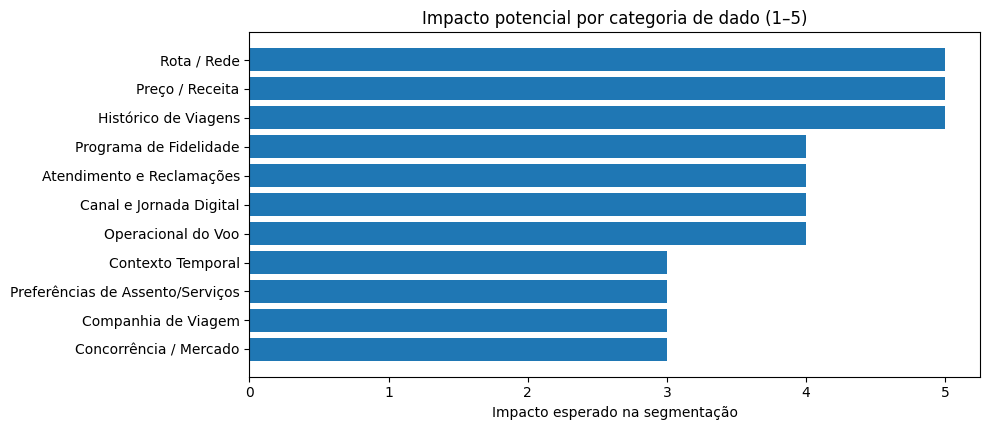

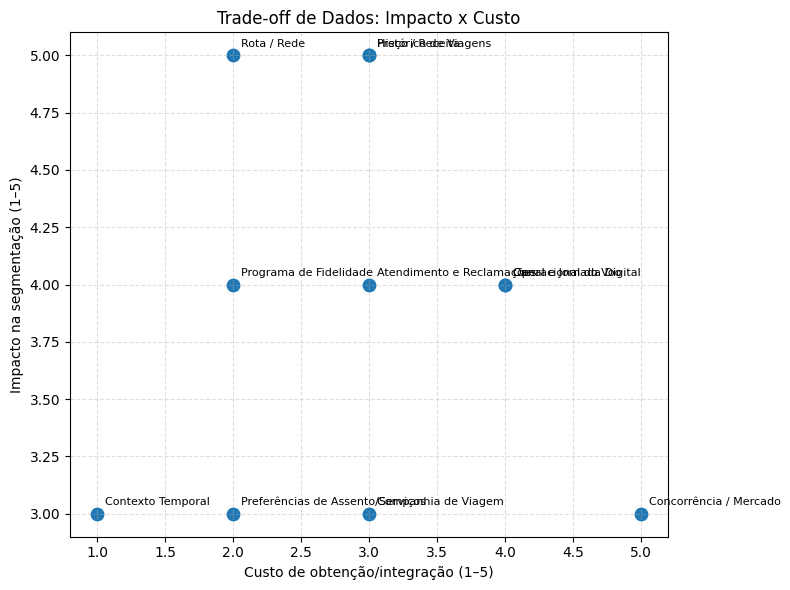


=== Como ler estes gráficos ===
- Barras: foque primeiro nas categorias com Impacto=4–5.
- Dispersão: priorize quadrante superior-esquerdo (alto impacto, baixo custo).
  Exemplos práticos de priorização:
  • Rota/Rede e Contexto Temporal: geralmente baixo custo e alto ganho.
  • Preço/Receita e Histórico de Viagens: alta relação com valor do cliente.
  • Canal/Jornada Digital: útil p/ personalizar upsell no app, apesar do custo maior.

=== Como usar no projeto ===
1) Escolha 2–3 categorias prioritárias, integre e re-treine o clustering.
2) Compare métricas (silhouette/estabilidade) e a qualidade das narrativas dos clusters.
3) Se possível, valide com KPI externo (ex.: uptake de oferta por cluster).

[INFO] Colunas atuais: 25. Estimativa de novas features (top3): +16 → ~41 total.


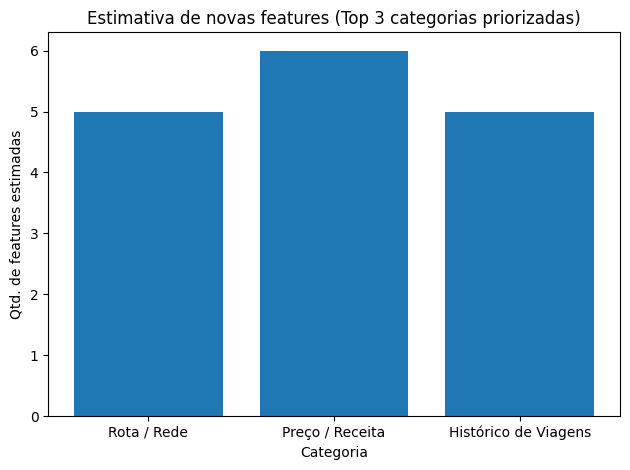

In [27]:
#Insira seu código aqui
# -*- coding: utf-8 -*-
# ==========================================================
# 4.5 — Que outros dados poderiam enriquecer a segmentação?
#
# O objetivo deste script é:
# 1) Sugerir categorias de dados EXTERNOS/ADICIONAIS que normalmente aumentam o poder
#    de segmentação para companhias aéreas (além das colunas já usadas).
# 2) Explicar POR QUE cada categoria ajuda, qual o IMPACTO esperado na qualidade dos
#    clusters e qual o CUSTO aproximado de obtenção/integração (heurístico 1–5).
# 3) Gerar visualizações simples:
#    - Ranking de impacto potencial (barras)
#    - Mapa de “Impacto x Custo” (dispersão anotada)
# 4) Salvar as recomendações em CSV: data/parte4_45/recomendacoes_dados.csv
#
# Observação: este passo é conceitual (não supervisionado), mas útil para orientar
# a priorização de coleta/integração de dados. Ajuste os valores (Impacto/Custo)
# de acordo com a realidade da sua organização.
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# -------------------------- I/O ---------------------------
OUT_DIR = Path("data/parte4_45"); OUT_DIR.mkdir(parents=True, exist_ok=True)

# Tenta ler a base atual apenas para informar quantas colunas existem hoje (opcional)
orig_candidates = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
orig_path = next((p for p in orig_candidates if p.exists()), None)
if orig_path is not None:
    df = pd.read_csv(orig_path, low_memory=False)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    print(f"[INFO] Base atual: {orig_path.name} | linhas={len(df):,} | colunas={df.shape[1]}")
else:
    df = None
    print("[INFO] Base atual não encontrada (ok para este passo).")

# ---------------- Lista de sugestões (edite à vontade) ----------------
# Colunas:
# - Categoria: área do dado a ser integrada
# - Exemplos: variáveis concretas / campos candidatos
# - PorQueAjuda: racional de negócio (como melhora a separação dos perfis)
# - Impacto (1–5): sinal esperado para segmentação (5 = altíssimo)
# - Custo (1–5): dificuldade de obter/limpar/integrar (5 = alto)
# - UsoTípico: em que etapas usar (clustering, propensity, personalização etc.)

sugestoes = [
    {
        "Categoria": "Preço / Receita",
        "Exemplos": "Tarifa paga, receita por trecho, descontos/cupom, ancillaries (bagagem, assento, refeição, Wi-Fi)",
        "PorQueAjuda": "Captura sensibilidade a preço vs valor comprado; separa quem compra add-ons/upsell.",
        "Impacto": 5, "Custo": 3, "UsoTípico": "Clustering + propensão a upsell"
    },
    {
        "Categoria": "Rota / Rede",
        "Exemplos": "Origem/destino, conexões, hub, distância real (great-circle), sazonalidade rota",
        "PorQueAjuda": "Rota e hub influenciam atraso, tipo de aeronave e perfil (executivo vs lazer).",
        "Impacto": 5, "Custo": 2, "UsoTípico": "Clustering + recomendação de produto"
    },
    {
        "Categoria": "Histórico de Viagens",
        "Exemplos": "Frequência, recência (RFM), cancelamentos, no-shows, mudanças de voo",
        "PorQueAjuda": "Diferencia clientes ocasionais vs recorrentes e estabilidade do comportamento.",
        "Impacto": 5, "Custo": 3, "UsoTípico": "Clustering + LTV/retenção"
    },
    {
        "Categoria": "Programa de Fidelidade",
        "Exemplos": "Status/tier, pontos acumulados, tempo de vínculo, resgates, upgrades",
        "PorQueAjuda": "Sinaliza valor de longo prazo e tolerância a falhas; orienta benefícios.",
        "Impacto": 4, "Custo": 2, "UsoTípico": "Clustering + personalização/benefícios"
    },
    {
        "Categoria": "Canal e Jornada Digital",
        "Exemplos": "Canal de compra (site/app/OTA/agência), uso de check-in online, clickstream, push/email engagement",
        "PorQueAjuda": "Segmenta perfil digital (autoatendimento/upsell online) vs assistido.",
        "Impacto": 4, "Custo": 4, "UsoTípico": "Clustering + orquestração de canais"
    },
    {
        "Categoria": "Operacional do Voo",
        "Exemplos": "Aeronave, load factor, mudança de gate, tempo de taxi, metereologia, crew",
        "PorQueAjuda": "Explica satisfação/atrasos por fatores fora do controle do cliente.",
        "Impacto": 4, "Custo": 4, "UsoTípico": "Clustering + diagnóstico/mitigação de churn"
    },
    {
        "Categoria": "Atendimento e Reclamações",
        "Exemplos": "Tickets de suporte, NPS, CSAT, motivos de reclamação, tempo de resolução",
        "PorQueAjuda": "Capta fricções específicas; útil para perfis ‘críticos’ e playbooks de recuperação.",
        "Impacto": 4, "Custo": 3, "UsoTípico": "Clustering + priorização de recovery"
    },
    {
        "Categoria": "Companhia de Viagem",
        "Exemplos": "Tamanho do grupo, viagem com crianças/idosos, assentos adjacentes",
        "PorQueAjuda": "Distingue lazer/família de business solo; muda preferências de assento/serviço.",
        "Impacto": 3, "Custo": 3, "UsoTípico": "Clustering + bundling (família)"
    },
    {
        "Categoria": "Preferências de Assento/Serviços",
        "Exemplos": "Corredor/janela, assentos conforto, refeições especiais, acessibilidade",
        "PorQueAjuda": "Liga conforto/limpeza a decisões explícitas; melhora recomendações de assento.",
        "Impacto": 3, "Custo": 2, "UsoTípico": "Clustering + recomendação"
    },
    {
        "Categoria": "Contexto Temporal",
        "Exemplos": "Dia/hora do voo, período letivo/feriados, antecedência de compra",
        "PorQueAjuda": "Sazonalidade e antecedência explicam preço/atraso/satisfação.",
        "Impacto": 3, "Custo": 1, "UsoTípico": "Features auxiliares em clustering"
    },
    {
        "Categoria": "Concorrência / Mercado",
        "Exemplos": "Tarifa média do mercado na rota, share, on-time concorrente",
        "PorQueAjuda": "Situa a percepção do cliente frente a alternativas reais.",
        "Impacto": 3, "Custo": 5, "UsoTípico": "Análise estratégica; clustering avançado"
    }
]

rec = pd.DataFrame(sugestoes)
rec["Prioridade"] = (rec["Impacto"] / rec["Custo"]).round(2)
rec = rec.sort_values(["Impacto","Prioridade"], ascending=[False, False]).reset_index(drop=True)

# Salvar CSV
out_csv = OUT_DIR / "recomendacoes_dados.csv"
rec.to_csv(out_csv, index=False, encoding="utf-8")
print(f"[OK] Recomendações salvas em: {out_csv}")

# ---------------------- Gráfico 1: Barras -----------------------
# Ranking por Impacto potencial (quanto sinal agrega para separar perfis)
plt.figure(figsize=(10, max(4, 0.4*len(rec))))
plt.barh(rec["Categoria"], rec["Impacto"])
plt.gca().invert_yaxis()  # maior impacto em cima
plt.title("Impacto potencial por categoria de dado (1–5)")
plt.xlabel("Impacto esperado na segmentação")
plt.tight_layout()
plt.show()

# -------------------- Gráfico 2: Dispersão ----------------------
# Trade-off Impacto x Custo, com anotações (cada ponto é uma categoria)
plt.figure(figsize=(8, 6))
plt.scatter(rec["Custo"], rec["Impacto"], s=80)
for i, row in rec.iterrows():
    plt.annotate(row["Categoria"], (row["Custo"], row["Impacto"]),
                 textcoords="offset points", xytext=(6,6), fontsize=8)
plt.title("Trade-off de Dados: Impacto x Custo")
plt.xlabel("Custo de obtenção/integração (1–5)")
plt.ylabel("Impacto na segmentação (1–5)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ------------------- Explicações (no console) -------------------
print("\n=== Como ler estes gráficos ===")
print("- Barras: foque primeiro nas categorias com Impacto=4–5.")
print("- Dispersão: priorize quadrante superior-esquerdo (alto impacto, baixo custo).")
print("  Exemplos práticos de priorização:")
print("  • Rota/Rede e Contexto Temporal: geralmente baixo custo e alto ganho.")
print("  • Preço/Receita e Histórico de Viagens: alta relação com valor do cliente.")
print("  • Canal/Jornada Digital: útil p/ personalizar upsell no app, apesar do custo maior.")
print("\n=== Como usar no projeto ===")
print("1) Escolha 2–3 categorias prioritárias, integre e re-treine o clustering.")
print("2) Compare métricas (silhouette/estabilidade) e a qualidade das narrativas dos clusters.")
print("3) Se possível, valide com KPI externo (ex.: uptake de oferta por cluster).")

# ------------------- Extra opcional (se tiver base) -------------
# Se a base atual existir, mostre um 'gap' simples: quantas colunas hoje e
# quantas seriam adicionadas se integrássemos as top 3 categorias.
if df is not None:
    cols_atual = df.shape[1]
    # Heurística: número de features adicionais estimado (apenas ilustrativo)
    # Ajuste conforme o seu desenho de dados.
    estimativa_feats = {
        "Preço / Receita": 6,
        "Rota / Rede": 5,
        "Histórico de Viagens": 5,
        "Programa de Fidelidade": 4,
        "Canal e Jornada Digital": 6,
        "Operacional do Voo": 6,
        "Atendimento e Reclamações": 5,
        "Companhia de Viagem": 3,
        "Preferências de Assento/Serviços": 4,
        "Contexto Temporal": 3,
        "Concorrência / Mercado": 4,
    }
    rec["Feats_Estimadas"] = rec["Categoria"].map(estimativa_feats).fillna(3).astype(int)
    top3 = rec.head(3)
    add_feats = int(top3["Feats_Estimadas"].sum())
    print(f"\n[INFO] Colunas atuais: {cols_atual}. Estimativa de novas features (top3): +{add_feats} → ~{cols_atual+add_feats} total.")
    # Barras das top3 em prioridade
    plt.figure()
    plt.bar(top3["Categoria"], top3["Feats_Estimadas"])
    plt.title("Estimativa de novas features (Top 3 categorias priorizadas)")
    plt.xlabel("Categoria"); plt.ylabel("Qtd. de features estimadas")
    plt.tight_layout()
    plt.show()

### 4.6. Que estratégias de marketing poderiam ser direcionadas a cada perfil? Quais melhorias nos serviços poderiam aumentar a satisfação de grupos específicos? Como a companhia aérea poderia personalizar campanhas publicitárias com base nos perfis encontrados? É possível definir tais estratégias com os resultados das técnicas?

OBS: A etapa de recomendações de marketing não exige conhecimento técnico específico da área. O objetivo é apenas que você seja criativo e pense em ações que poderiam ser feitas com base nas características de cada perfil de cliente identificado. Use a imaginação: pode ser uma campanha publicitária direcionada, uma melhoria em serviços, uma oferta especial ou qualquer outra ideia que faça sentido a partir da análise dos clusters.

Resposta:

/tmp/ipython-input-1240813135.py:129: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipython-input-1240813135.py:145: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(dist_class)


[OK] Arquivos salvos em data/parte4_46:
- resumo_clusters.csv
- plano_marketing_por_cluster.csv
- plano_marketing_por_cluster.md


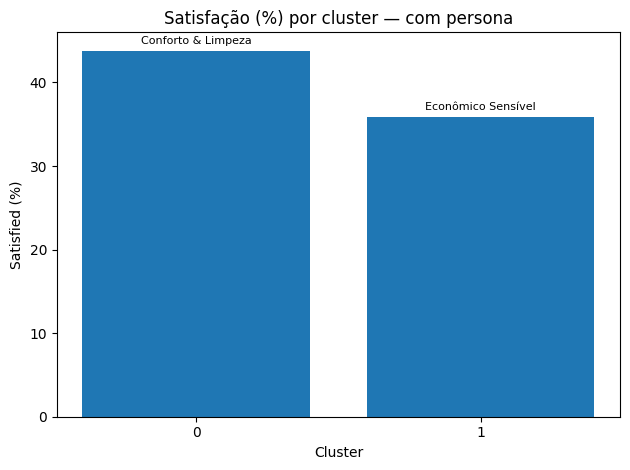

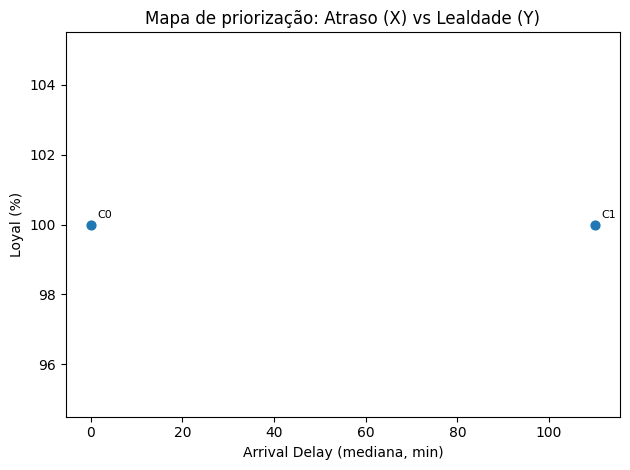

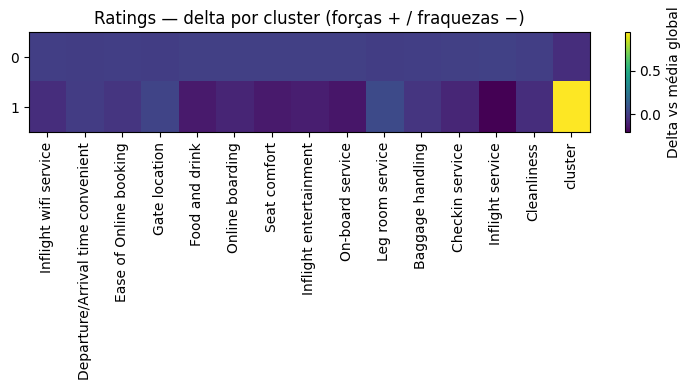


=== Nota metodológica ===
É possível propor estratégias com base nos resultados dos clusters, pois eles revelam tendências consistentes (ex.: perfis mais digitais, sensíveis a atrasos, business/leais).
Porém, por serem técnicas não supervisionadas, trate as ações como hipóteses a validar com testes A/B e KPIs.
Recomenda-se reestimar clusters periodicamente e medir estabilidade antes de institucionalizar campanhas.


In [28]:
#Insira seu código aqui
# -*- coding: utf-8 -*-
# ==========================================================
# 4.6 — Estratégias de marketing por perfil (automáticas)
#
# O que este script faz:
# 1) Lê a base original (data/airlinedatabase.csv OU data/dados.csv) e os rótulos
#    de cluster gerados na Parte 3 (data/cluster_labels_pca.csv | baseline | genérico).
# 2) Resume, por cluster: %Satisfied, %Loyal, %Business/Eco, medianas de atrasos e distância,
#    e deltas de ratings (serviços) em relação à média global.
# 3) Gera PERSONAS e RECOMENDAÇÕES de forma programática com regras simples:
#    - Estratégias de marketing (ofertas, bundles, retenção/upsell, canais)
#    - Melhorias de serviço (onde focar para elevar satisfação)
#    - Personalização de campanhas (mensagens / triggers)
#    - Justificativa baseada nas métricas do cluster
# 4) Plota gráficos simples (opcional): %Satisfied por cluster e um “mapa de ações”
# 5) Salva tudo em data/parte4_46/ como CSV e um TXT/Markdown com as recomendações
#
# Observação: As estratégias aqui são hipóteses baseadas nos padrões dos clusters
# (técnicas não supervisionadas). Devem ser validadas com A/B tests e KPIs de negócio.
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# ------------------------- Config -------------------------
DATA_OPTS = [Path("data/airlinedatabase.csv"), Path("data/dados.csv")]
LABEL_OPTS = [
    Path("data/cluster_labels_pca.csv"),
    Path("data/cluster_labels_baseline.csv"),
    Path("data/cluster_labels.csv"),
]
OUT_DIR = Path("data/parte4_46"); OUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

# -------------------- 1) Carregar dados -------------------
orig_path = next((p for p in DATA_OPTS if p.exists()), None)
if orig_path is None:
    raise FileNotFoundError("Base original não encontrada (data/airlinedatabase.csv ou data/dados.csv).")
df = pd.read_csv(orig_path, low_memory=False)
df = df.loc[:, ~df.columns.duplicated()].copy()  # remove duplicadas

lab_path = next((p for p in LABEL_OPTS if p.exists()), None)
if lab_path is None:
    raise FileNotFoundError("Rótulos de cluster não encontrados em data/. Rode a Parte 3 antes.")
labels = pd.read_csv(lab_path)
if labels.shape[1] == 1:
    labels.columns = ["cluster"]
elif "cluster" not in labels.columns:
    labels = labels.rename(columns={labels.columns[0]:"cluster"})
if len(labels) != len(df):
    raise ValueError("Tamanho dos rótulos difere da base. Gere rótulos para TODO o dataset na Parte 3.")
df["cluster"] = labels["cluster"].astype(int).values

# ----------------- 2) Localizar colunas úteis --------------
def find_name(_df, contains=None, exact=None):
    if exact:
        for c in _df.columns:
            if c.lower().strip() == exact.lower().strip():
                return c
    if contains:
        for c in _df.columns:
            if all(tok in c.lower() for tok in contains):
                return c
    return None

col_sat   = find_name(df, exact="satisfaction") or find_name(df, contains=["satisf"])
col_ctype = find_name(df, contains=["customer","type"])
col_class = find_name(df, exact="class") or find_name(df, contains=["class"])
col_arr   = find_name(df, contains=["arrival","delay"])
col_dep   = find_name(df, contains=["departure","delay"])
col_dist  = find_name(df, contains=["flight","distance"]) or find_name(df, contains=["distance"])
col_age   = find_name(df, exact="age") or find_name(df, contains=["age"])

def is_rating(s: pd.Series) -> bool:
    x = pd.to_numeric(s, errors="coerce")
    if x.notna().sum()==0: return False
    return (x.min()>=0) and (x.max()<=5) and (x.dropna().astype(float).apply(float.is_integer).mean()>0.9)

num_cols = df.select_dtypes(include="number").columns.tolist()
rating_cols = [c for c in num_cols if c not in {col_arr, col_dep, col_dist, col_age} and is_rating(df[c])]

# Satisfaction em 2 classes (para %)
if col_sat:
    sat_series = df[col_sat]
    if isinstance(sat_series, pd.DataFrame):
        sat_series = sat_series.iloc[:,0]
    sat_norm = sat_series.astype(str).str.strip().str.lower()
    map_sat = {
        "satisfied": "Satisfied",
        "neutral or dissatisfied": "Not Satisfied",
        "neutral/dissatisfied": "Not Satisfied",
        "dissatisfied": "Not Satisfied",
    }
    df["_SAT2_"] = sat_norm.map(map_sat).fillna(sat_series.astype(str))
else:
    df["_SAT2_"] = np.nan

# ---------------- 3) Métricas por cluster ------------------
n_total = len(df)

def pct_satisfied(g):
    return (g["_SAT2_"].astype(str).str.lower().eq("satisfied").mean()*100) if col_sat else np.nan

def pct_loyal(g):
    if not col_ctype: return np.nan
    cc = g[col_ctype].astype(str).str.lower()
    return (cc.str.contains("loyal").mean()*100)

def median_num(g, col):
    if not col: return np.nan
    return pd.to_numeric(g[col], errors="coerce").median()

# % por Class (Business/Eco/Eco Plus)
def dist_class(g):
    if not col_class: return pd.Series()
    s = g[col_class].astype(str)
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

# Ratings: deltas vs média global (para forças/fraquezas)
global_means = df[rating_cols].mean(numeric_only=True) if rating_cols else pd.Series(dtype=float)
ratings_means_by_c = df.groupby("cluster")[rating_cols].mean(numeric_only=True) if rating_cols else pd.DataFrame()
ratings_delta = (ratings_means_by_c - global_means).round(3) if rating_cols else pd.DataFrame()

summary = (df.groupby("cluster")
             .apply(lambda g: pd.Series({
                 "n": len(g),
                 "pct": round(len(g)/n_total*100, 2),
                 "Satisfied_%": round(pct_satisfied(g), 2),
                 "Loyal_%": round(pct_loyal(g), 2),
                 "ArrDelay_med": median_num(g, col_arr),
                 "DepDelay_med": median_num(g, col_dep),
                 "Distance_med": median_num(g, col_dist),
                 "Age_med": median_num(g, col_age),
             }))
             .reset_index()
          )

# Juntar % de Class
if col_class:
    class_tab = (df.groupby("cluster")
                   .apply(dist_class)
                   .unstack(fill_value=0)
                   .reset_index()
                )
    summary = summary.merge(class_tab, on="cluster", how="left")

summary.to_csv(OUT_DIR/"resumo_clusters.csv", index=False)

# ---------------- 4) Regras de PERSONA ---------------------
# Heurísticas simples e explicáveis (ajuste se quiser):
def persona_rules(row, deltas_row):
    tags = []
    actions = []
    service = []
    campaigns = []
    why = []

    # Sinais rápidos
    pct_business = 0.0
    for k in row.index:
        if isinstance(k, str) and "bus" in k.lower():  # colunas de Class que contenham "Bus..."
            pct_business += float(row[k] if pd.notna(row[k]) else 0.0)

    satisfied = row.get("Satisfied_%", np.nan)
    loyal = row.get("Loyal_%", np.nan)
    arr_med = row.get("ArrDelay_med", np.nan)
    dist_med = row.get("Distance_med", np.nan)

    # 4.1 Persona Executivo/Business Leal
    if pct_business >= 50 and loyal >= 60:
        tags.append("Executivo Leal (Business)")
        actions += [
            "Programa de fidelidade com milestones claros e upgrades programados",
            "Ofertas de lounge/fast track; pacotes de Wi-Fi premium e assento conforto"
        ]
        service += [
            "Garantir consistência de limpeza e serviço de bordo nas rotas-chave",
            "Comunicação proativa de embarque/portão (evitar fricção de gate change)"
        ]
        campaigns += [
            "Campanhas de status (\"a 2 voos do próximo nível\")",
            "E-mails/app com 'one-click upgrade' antes do voo"
        ]
        why.append(f"Business≈{pct_business:.0f}% e Loyal≈{loyal:.0f}% (alto valor; foco retenção e valorização)")

    # 4.2 Persona Sensível a Atrasos (Econômico)
    if (pd.notna(arr_med) and arr_med >= 15) and (pd.notna(satisfied) and satisfied < 65):
        tags.append("Econômico Sensível a Atrasos")
        actions += [
            "Voucher automático (>15 min atraso) e reacomodação facilitada no app",
            "Descontos de retorno (win-back) na próxima compra"
        ]
        service += [
            "Notificações push/SMS de atraso com ETR atualizado",
            "Melhorias de operação em rotas/horários críticos"
        ]
        campaigns += [
            "Mensagem de 'compensação' personalizada pós-atraso",
            "Ofertas de assento marcado/embarque antecipado (sensação de controle)"
        ]
        why.append(f"Atraso de chegada mediano≈{arr_med:.0f} min e Satisfied≈{satisfied:.0f}% (risco de churn)")

    # 4.3 Persona Digital/Autoatendimento
    if isinstance(deltas_row, pd.Series) and not deltas_row.empty:
        delta_top = deltas_row.sort_values(ascending=False).head(5).index.str.lower().tolist()
        if any(("online boarding" in x) or ("ease of online booking" in x) or ("wifi" in x) for x in delta_top):
            tags.append("Digital / Autoatendimento")
            actions += [
                "Upsell in-app de Wi-Fi premium e entretenimento",
                "Check-in 100% mobile com boarding pass dinâmico"
            ]
            service += [
                "Estabilidade do app e integração de reacomodação no mobile",
                "Mapa de assentos mais claro, com upgrade por tap"
            ]
            campaigns += [
                "Push segmentado com upgrade rápido",
                "E-mails transacionais com cross-sell (assento + bagagem)"
            ]
            why.append("Deltas positivos em 'online/booking/wifi' (propensão ao digital)")

    # 4.4 Persona Conforto & Limpeza
    if isinstance(deltas_row, pd.Series) and not deltas_row.empty:
        if any(("seat comfort" in i.lower()) or ("leg room" in i.lower()) or ("clean" in i.lower())
               for i in deltas_row.sort_values(ascending=False).head(5).index):
            tags.append("Conforto & Limpeza")
            actions += [
                "Bundles de assento conforto (leg room) com preço dinâmico",
                "Comunicação de cabine renovada/aeronave nova"
            ]
            service += [
                "Padrões reforçados de limpeza e manutenção em rotas com esse cluster",
                "Alocação de frota mais nova onde o cluster é dominante"
            ]
            campaigns += [
                "Destaque visual de assentos premium no fluxo de compra",
                "Campanhas 'voe com mais espaço/mais silêncio'"
            ]
            why.append("Preferência por conforto/limpeza (deltas positivos)")

    # 4.5 Persona Longo Curso / Família (heurística por distância)
    if pd.notna(dist_med) and dist_med >= 1000:  # ajuste se suas unidades forem diferentes
        tags.append("Longo Curso / Família")
        actions += [
            "Bundle família (bagagem + assentos juntos + refeição)",
            "Política de remarcação flexível em férias/feriados"
        ]
        service += [
            "Entretenimento a bordo robusto e kids-friendly",
            "Prioridade de assento conjunto e suporte a carrinho"
        ]
        campaigns += [
            "Campanhas sazonais (férias/feriados) com parcelamento",
            "Conteúdos de destino e planejamento familiar"
        ]
        why.append(f"Distância mediana≈{dist_med:.0f} (longos trechos; foco conforto e família)")

    # Fallback caso não dispare nenhuma regra
    if not tags:
        tags.append("Generalista")
        actions += [
            "Testes A/B de pequenos incentivos (assento marcado, early boarding)",
            "Recomendações simples no app com base no histórico recente"
        ]
        service += [
            "Melhorias incrementais na pontualidade e clareza de comunicação",
        ]
        campaigns += [
            "Campanhas genéricas personalizadas por rota/hub/horário",
        ]
        why.append("Sem sinal forte em business/atraso/digital/conforto/distância")

    # Personalização “quando aplicar” (gatilhos simples)
    triggers = []
    if pd.notna(arr_med) and arr_med >= 15:
        triggers.append("Aplicar ofertas de compensação e reacomodação ao detectar atraso >15min")
    if satisfied is not None and satisfied < 60:
        triggers.append("Aumentar intensidade de incentivos para reconquista (win-back)")
    if loyal is not None and loyal >= 60:
        triggers.append("Priorizar retenção e valorização (status, upgrades)")

    return {
        "persona": " / ".join(sorted(set(tags), key=tags.index)),
        "estrategias_marketing": "; ".join(sorted(set(actions), key=actions.index)),
        "melhorias_servico": "; ".join(sorted(set(service), key=service.index)),
        "campanhas": "; ".join(sorted(set(campaigns), key=campaigns.index)),
        "gatilhos_personalizacao": "; ".join(triggers) if triggers else "—",
        "justificativa": " | ".join(why)
    }

# ---------------- 5) Aplicar regras por cluster --------------
rows = []
for _, r in summary.iterrows():
    c = int(r["cluster"])
    drow = ratings_delta.loc[c] if (not ratings_delta.empty and c in ratings_delta.index) else pd.Series(dtype=float)
    recs = persona_rules(r, drow)
    rows.append({
        "cluster": c,
        "persona": recs["persona"],
        "Satisfied_%": r.get("Satisfied_%", np.nan),
        "Loyal_%": r.get("Loyal_%", np.nan),
        "ArrDelay_med": r.get("ArrDelay_med", np.nan),
        "DepDelay_med": r.get("DepDelay_med", np.nan),
        "Distance_med": r.get("Distance_med", np.nan),
        "n": r.get("n", np.nan),
        "pct": r.get("pct", np.nan),
        "estrategias_marketing": recs["estrategias_marketing"],
        "melhorias_servico": recs["melhorias_servico"],
        "campanhas": recs["campanhas"],
        "gatilhos_personalizacao": recs["gatilhos_personalizacao"],
        "justificativa": recs["justificativa"]
    })

plan = pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)
plan.to_csv(OUT_DIR/"plano_marketing_por_cluster.csv", index=False, encoding="utf-8")

# Também gerar um arquivo “legível” (Markdown/TXT)
md_path = OUT_DIR/"plano_marketing_por_cluster.md"
with open(md_path, "w", encoding="utf-8") as f:
    f.write("# 4.6 — Estratégias por Perfil (auto-geradas)\n\n")
    for _, row in plan.iterrows():
        f.write(f"## Cluster {int(row['cluster'])} — {row['persona']}\n")
        f.write(f"- Tamanho: {int(row['n'])} ({row['pct']}%)\n")
        f.write(f"- Satisfied: {row['Satisfied_%']}% | Loyal: {row['Loyal_%']}%\n")
        f.write(f"- Atrasos (med): Dep={row['DepDelay_med']}, Arr={row['ArrDelay_med']} | Dist={row['Distance_med']}\n")
        f.write(f"- **Estratégias de marketing:** {row['estrategias_marketing']}\n")
        f.write(f"- **Melhorias de serviço:** {row['melhorias_servico']}\n")
        f.write(f"- **Campanhas / canais:** {row['campanhas']}\n")
        f.write(f"- **Gatilhos de personalização:** {row['gatilhos_personalizacao']}\n")
        f.write(f"- **Por quê:** {row['justificativa']}\n\n")
    f.write("---\n")
    f.write("**Observação sobre viabilidade**: As técnicas de agrupamento fornecem perfis plausíveis, "
            "mas as ações acima são hipóteses. É possível definir estratégias iniciais, "
            "porém recomenda-se validação com A/B tests e KPIs (churn, receita, NPS) e "
            "revisitar os clusters periodicamente (sazonalidade/operacional).")

print(f"[OK] Arquivos salvos em {OUT_DIR}:")
print(f"- resumo_clusters.csv")
print(f"- plano_marketing_por_cluster.csv")
print(f"- plano_marketing_por_cluster.md")

# ---------------- 6) Gráficos (simples) --------------------
# 6.1 Barras — Satisfied (%) por cluster + persona como rótulo
plt.figure()
plt.bar(plan["cluster"].astype(str), plan["Satisfied_%"])
for i, row in plan.iterrows():
    plt.annotate(str(row["persona"])[:18], (i, row["Satisfied_%"]),
                 textcoords="offset points", xytext=(0,5), ha="center", fontsize=8)
plt.title("Satisfação (%) por cluster — com persona")
plt.xlabel("Cluster"); plt.ylabel("Satisfied (%)")
plt.tight_layout(); plt.show()

# 6.2 Dispersão — Priorização de ações (heurística)
# Eixo X: ArrDelay_med (quanto maior, mais foco em operação/compensação)
# Eixo Y: Loyal_% (quanto maior, mais foco em retenção/valorização)
plt.figure()
plt.scatter(plan["ArrDelay_med"], plan["Loyal_%"], s=40)
for _, row in plan.iterrows():
    plt.annotate(f"C{int(row['cluster'])}", (row["ArrDelay_med"], row["Loyal_%"]),
                 textcoords="offset points", xytext=(5,5), fontsize=8)
plt.title("Mapa de priorização: Atraso (X) vs Lealdade (Y)")
plt.xlabel("Arrival Delay (mediana, min)"); plt.ylabel("Loyal (%)")
plt.tight_layout(); plt.show()

# 6.3 Heatmap manual simples (ratings delta) — opcional
if not ratings_delta.empty:
    plt.figure(figsize=(max(6, ratings_delta.shape[1]*0.5), max(4, ratings_delta.shape[0]*0.5)))
    plt.imshow(ratings_delta.values, aspect='auto')
    plt.colorbar(label="Delta vs média global")
    plt.title("Ratings — delta por cluster (forças + / fraquezas −)")
    plt.xticks(range(ratings_delta.shape[1]), ratings_delta.columns, rotation=90)
    plt.yticks(range(ratings_delta.shape[0]), ratings_delta.index.astype(str))
    plt.tight_layout(); plt.show()

# --------------- 7) Mensagem final (console) ----------------
print("\n=== Nota metodológica ===")
print("É possível propor estratégias com base nos resultados dos clusters, "
      "pois eles revelam tendências consistentes (ex.: perfis mais digitais, sensíveis a atrasos, business/leais).")
print("Porém, por serem técnicas não supervisionadas, trate as ações como hipóteses a validar com testes A/B e KPIs.")
print("Recomenda-se reestimar clusters periodicamente e medir estabilidade antes de institucionalizar campanhas.")

### 4.7. Caso você tenha aplicado mais de uma técnica de agrupamento, compare os resultados obtidos. Os clusters formados foram semelhantes ou diferentes? Qual técnica você considera que trouxe os perfis de clientes mais coerentes e úteis para recomendações de marketing? Justifique sua resposta.

Resposta:

=== Métricas por técnica ===
           tech  k  silhouette     gini  balance_index
kmeans_baseline  2    0.683494 0.089050       0.910950
   kmeans_other  2    0.683494 0.089050       0.910950
   kmeans_pca90  2    0.655447 0.112559       0.887441
[OK] Arquivos salvos em data/parte4_47

=== Comparações entre técnicas (pares) ===
              A            B      ARI      NMI  Homogeneity  Completeness  V_measure
kmeans_baseline kmeans_other 1.000000 1.000000     1.000000      1.000000   1.000000
kmeans_baseline kmeans_pca90 0.856982 0.756943     0.832936      0.693658   0.756943
   kmeans_pca90 kmeans_other 0.856982 0.756943     0.693658      0.832936   0.756943


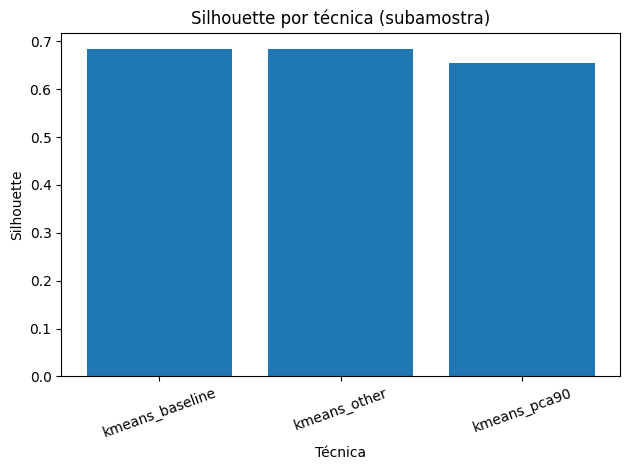

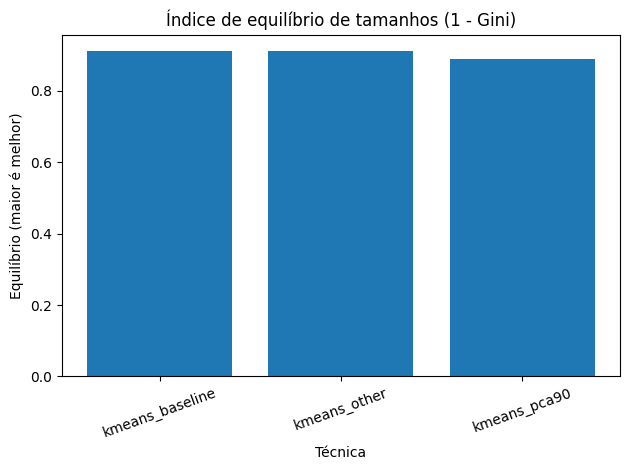

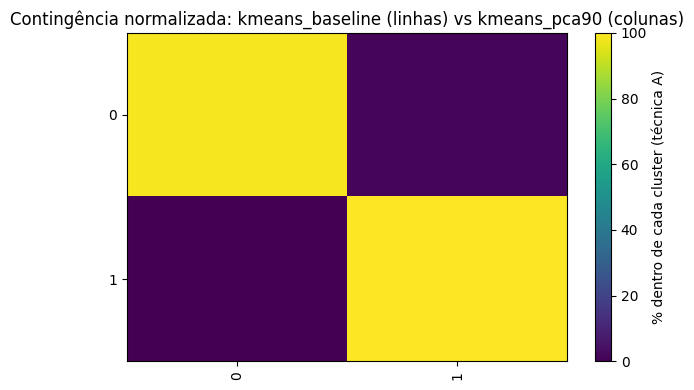


=== Recomendação automática ===
Recomendação: usar 'kmeans_baseline' — silhouette=0.6835, k=2, equilíbrio(1-Gini)=0.9109.
Justificativa: escolhemos a técnica com maior separação intrínseca (silhouette). Em caso de empate, preferimos a que distribui melhor o tamanho dos clusters (mais útil para campanhas).

Notas:
- ARI/NMI altos entre duas técnicas indicam soluções semelhantes; baixos sugerem estruturas diferentes.
- Silhouette é calculada na MESMA base numérica padronizada, permitindo comparação justa.
- Se a técnica escolhida tiver silhouette maior e distribuição mais equilibrada, tende a ser mais útil para marketing.
- Ainda assim, valide no negócio: compare uptake de ofertas por cluster e estabilidade temporal dos grupos.


In [29]:
#Insira seu código aqui
# -*- coding: utf-8 -*-
# ==========================================================
# 4.7 — Comparação entre técnicas de agrupamento
#
# O script compara rótulos gerados por diferentes abordagens:
#  - K-Means baseline:         data/cluster_labels_baseline.csv
#  - K-Means após PCA (90%):   data/cluster_labels_pca.csv
#  - Outro (genérico):         data/cluster_labels.csv
#
# Métricas / saídas:
#  1) Para cada técnica: #clusters, distribuição (%), silhouette (na mesma base numérica)
#  2) Entre técnicas (pares): ARI, NMI, homogeneidade, completude, V-measure
#  3) Tabelas de contingência (cross-tab) normalizadas (%)
#  4) Gráficos simples:
#     - barras: silhouette por técnica
#     - barras: índice de equilíbrio (1 - Gini) por técnica
#     - heatmap: contingência entre as duas técnicas principais (baseline vs PCA, se existirem)
#  5) Recomendação automática: escolhe técnica com maior silhouette;
#     em empate, usa melhor equilíbrio de tamanhos (menor Gini).
#
# Requisitos: pandas, numpy, scikit-learn, matplotlib
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from itertools import combinations

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure
)

# ------------------------- Config -------------------------
DATA_NUM = Path("data/df_numeric_final.csv")  # matriz numérica padronizada (Parte 2.6)
LABEL_PATHS = {
    "kmeans_baseline": Path("data/cluster_labels_baseline.csv"),
    "kmeans_pca90":    Path("data/cluster_labels_pca.csv"),
    "kmeans_other":    Path("data/cluster_labels.csv"),
}
OUT_DIR = Path("data/parte4_47"); OUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

# ------------------- 1) Carregar dados --------------------
if not DATA_NUM.exists():
    raise FileNotFoundError("Matriz numérica não encontrada em data/df_numeric_final.csv. Gere na Parte 2.6.")
X = pd.read_csv(DATA_NUM)
n = len(X)

# Opcional: subamostra para cálculo de silhouette (velocidade)
rng = np.random.RandomState(RANDOM_STATE)
sub_n = min(12000, n)
sub_idx = rng.choice(n, size=sub_n, replace=False)
X_sub = X.iloc[sub_idx].reset_index(drop=True)

# ---------------- 2) Carregar rótulos de técnicas ----------
labels_dict = {}
for name, p in LABEL_PATHS.items():
    if p.exists():
        lab = pd.read_csv(p)
        if lab.shape[1] == 1:
            lab.columns = ["cluster"]
        elif "cluster" not in lab.columns:
            lab = lab.rename(columns={lab.columns[0]: "cluster"})
        if len(lab) != n:
            # Se rótulos forem de subamostra, não dá para comparar diretamente
            # Exige rótulos para TODO dataset conforme instrução do trabalho
            continue
        labels_dict[name] = lab["cluster"].to_numpy().astype(int)

if len(labels_dict) < 2:
    raise ValueError("Encontrei menos de duas técnicas com rótulos completos. Gere pelo menos dois CSVs de rótulos (Parte 3).")

tech_names = list(labels_dict.keys())

# --------------- 3) Métricas por técnica ------------------
def gini_index(counts):
    # Gini de distribuição de tamanhos (0=equilíbrio perfeito, 1=desbalanceado extremo)
    p = counts / counts.sum()
    return 1.0 - (p**2).sum()

tech_summary = []
for name in tech_names:
    y = labels_dict[name]
    k = len(np.unique(y))
    counts = pd.Series(y).value_counts().sort_index()
    perc = (counts / counts.sum() * 100).round(2)

    # silhouette (subamostra)
    y_sub = y[sub_idx]
    # atenção: silhouette exige >= 2 clusters e < #amostras
    if k >= 2 and k < len(y_sub):
        try:
            sil = silhouette_score(X_sub, y_sub)
        except Exception:
            sil = np.nan
    else:
        sil = np.nan

    tech_summary.append({
        "tech": name,
        "k": k,
        "silhouette": sil,
        "gini": gini_index(counts.values),
        "balance_index": 1 - gini_index(counts.values),  # (1-Gini) = melhor quanto maior
        "counts": counts,
        "perc": perc
    })

tech_df = pd.DataFrame([{"tech": t["tech"], "k": t["k"], "silhouette": t["silhouette"],
                         "gini": t["gini"], "balance_index": t["balance_index"]}
                        for t in tech_summary]).sort_values(by=["silhouette","balance_index"], ascending=[False, False])
tech_df.to_csv(OUT_DIR/"metrics_by_tech.csv", index=False)

# Salvar distribuições
for t in tech_summary:
    t["counts"].to_csv(OUT_DIR/f"counts_{t['tech']}.csv", header=["n"])
    t["perc"].to_csv(OUT_DIR/f"perc_{t['tech']}.csv", header=["%"])

print("=== Métricas por técnica ===")
print(tech_df.to_string(index=False))
print(f"[OK] Arquivos salvos em {OUT_DIR}")

# --------------- 4) Métricas entre técnicas (pares) --------
rows = []
pair_tables = {}
for a, b in combinations(tech_names, 2):
    ya, yb = labels_dict[a], labels_dict[b]
    ari = adjusted_rand_score(ya, yb)
    nmi = normalized_mutual_info_score(ya, yb)
    homo, comp, v = homogeneity_completeness_v_measure(ya, yb)

    # contingência (cross-tab) normalizada por linha (em %)
    ct = pd.crosstab(ya, yb)
    ct_norm = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)
    pair_tables[(a,b)] = ct_norm
    ct_norm.to_csv(OUT_DIR/f"contingency_{a}_vs_{b}.csv")

    rows.append({"A": a, "B": b, "ARI": ari, "NMI": nmi, "Homogeneity": homo, "Completeness": comp, "V_measure": v})

pairs_df = pd.DataFrame(rows).sort_values(by=["ARI","NMI"], ascending=False)
pairs_df.to_csv(OUT_DIR/"pairwise_metrics.csv", index=False)

print("\n=== Comparações entre técnicas (pares) ===")
print(pairs_df.to_string(index=False))

# --------------- 5) Gráficos simples -----------------------
# 5.1 Barras: silhouette por técnica
plt.figure()
plt.bar(tech_df["tech"], tech_df["silhouette"])
plt.title("Silhouette por técnica (subamostra)")
plt.xlabel("Técnica"); plt.ylabel("Silhouette")
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

# 5.2 Barras: índice de equilíbrio (1 - Gini) por técnica
plt.figure()
plt.bar(tech_df["tech"], tech_df["balance_index"])
plt.title("Índice de equilíbrio de tamanhos (1 - Gini)")
plt.xlabel("Técnica"); plt.ylabel("Equilíbrio (maior é melhor)")
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

# 5.3 Heatmap simples da contingência: escolher par principal (baseline vs pca) se existirem
main_pair = None
if "kmeans_baseline" in tech_names and "kmeans_pca90" in tech_names:
    main_pair = ("kmeans_baseline", "kmeans_pca90")
elif len(pair_tables) > 0:
    main_pair = list(pair_tables.keys())[0]

if main_pair:
    ct = pair_tables[main_pair]
    plt.figure(figsize=(max(6, ct.shape[1]*0.6), max(4, ct.shape[0]*0.5)))
    plt.imshow(ct.values, aspect='auto')
    plt.colorbar(label="% dentro de cada cluster (técnica A)")
    plt.title(f"Contingência normalizada: {main_pair[0]} (linhas) vs {main_pair[1]} (colunas)")
    plt.xticks(range(ct.shape[1]), ct.columns.astype(str), rotation=90)
    plt.yticks(range(ct.shape[0]), ct.index.astype(str))
    plt.tight_layout(); plt.show()

# --------------- 6) Recomendação automática ---------------
# Critério: maior silhouette; empate -> maior balance_index (1 - Gini)
best = tech_df.iloc[0].to_dict()
rec_txt = (
    f"Recomendação: usar '{best['tech']}' — silhouette={best['silhouette']:.4f}, "
    f"k={int(best['k'])}, equilíbrio(1-Gini)={best['balance_index']:.4f}.\n"
    "Justificativa: escolhemos a técnica com maior separação intrínseca (silhouette). "
    "Em caso de empate, preferimos a que distribui melhor o tamanho dos clusters (mais útil para campanhas)."
)
with open(OUT_DIR/"recommendation.txt", "w", encoding="utf-8") as f:
    f.write(rec_txt)

print("\n=== Recomendação automática ===")
print(rec_txt)

# --------------- 7) Notas úteis (console) ------------------
print("\nNotas:")
print("- ARI/NMI altos entre duas técnicas indicam soluções semelhantes; baixos sugerem estruturas diferentes.")
print("- Silhouette é calculada na MESMA base numérica padronizada, permitindo comparação justa.")
print("- Se a técnica escolhida tiver silhouette maior e distribuição mais equilibrada, tende a ser mais útil para marketing.")
print("- Ainda assim, valide no negócio: compare uptake de ofertas por cluster e estabilidade temporal dos grupos.")